In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
TARGET = 'isFraud'

In [4]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.expand_frame_repr', False)

In [8]:
df_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
df_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

In [9]:
print('train_trancation shape:', df_transaction.shape)
print('train_identity shape:',   df_identity.shape)

train_trancation shape: (590540, 394)
train_identity shape: (144233, 41)


In [10]:
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')

In [11]:
print('Train shape:', df.shape)

Train shape: (590540, 434)


In [12]:
print('Data count:',  df[TARGET].shape[0])
print('Event count:', df[TARGET].sum())

Data count: 590540
Event count: 20663


In [13]:
sorted_df = df.sort_values(by='TransactionDT')

train_size = int(sorted_df.shape[0] * .7)
val_size   = int(sorted_df.shape[0] * .15)

train_df = sorted_df.iloc[:train_size]
val_df   = sorted_df.iloc[train_size: train_size + val_size]
test_df  = sorted_df.iloc[train_size + val_size:]

print('Train shape:',      train_df.shape, '\nTrain prevalence:',      train_df[TARGET].sum() / train_df.shape[0], '\n')
print('Validation shape:', val_df.shape,   '\nValidation prevalence:', val_df[TARGET].sum()   / val_df.shape[0],   '\n')
print('Test shape:',       test_df.shape,  '\nTrain prevalence:',      test_df[TARGET].sum()  / test_df.shape[0],  '\n')

Train shape: (413378, 434) 
Train prevalence: 0.03516878014795175 

Validation shape: (88581, 434) 
Validation prevalence: 0.03434145019812375 

Test shape: (88581, 434) 
Train prevalence: 0.03480430340592226 



In [14]:
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_val   = val_df.drop(columns=[TARGET])
y_val   = val_df[TARGET]

X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]

In [15]:
print('train_prevalence', y_train.mean())
print('test_prevalence',  y_test.mean())

train_prevalence 0.03516878014795175
test_prevalence 0.03480430340592226


# Data Prevalence

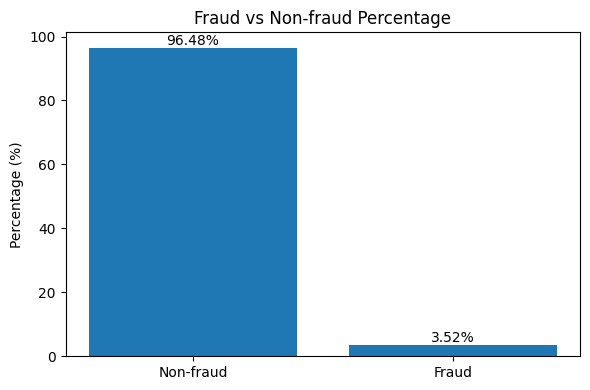

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

counts = train_df["isFraud"].value_counts().sort_index()
labels = ["Non-fraud", "Fraud"]

pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, pct)

ax.set_ylabel("Percentage (%)")
ax.set_title("Fraud vs Non-fraud Percentage")

for bar, value in zip(bars, pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# NaN plot

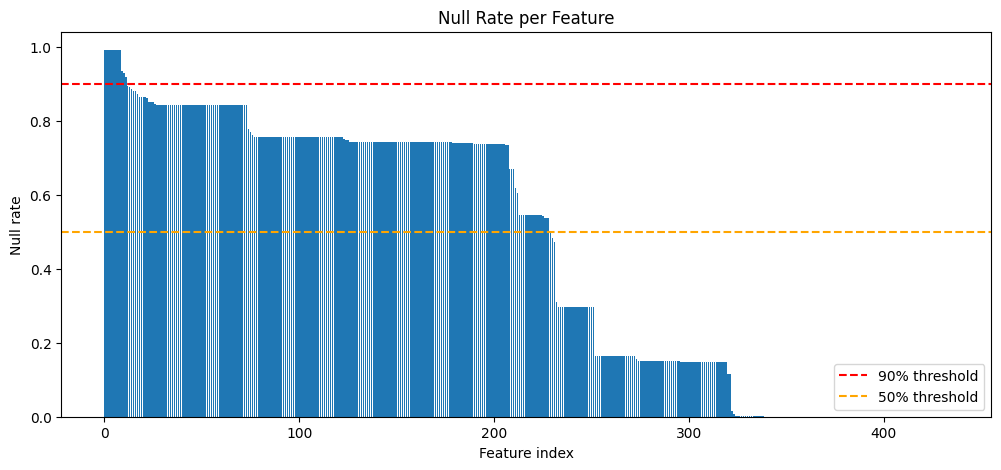

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

null_rates = train_df.isnull().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(null_rates)), null_rates.values)
ax.axhline(0.9, color='red', linestyle='--', label='90% threshold')
ax.axhline(0.5, color='orange', linestyle='--', label='50% threshold')
ax.set_title('Null Rate per Feature')
ax.set_xlabel('Feature index')
ax.set_ylabel('Null rate')
ax.legend()

# 'TransactionAmt' Outliers

/tmp/ipykernel_57/2203083758.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


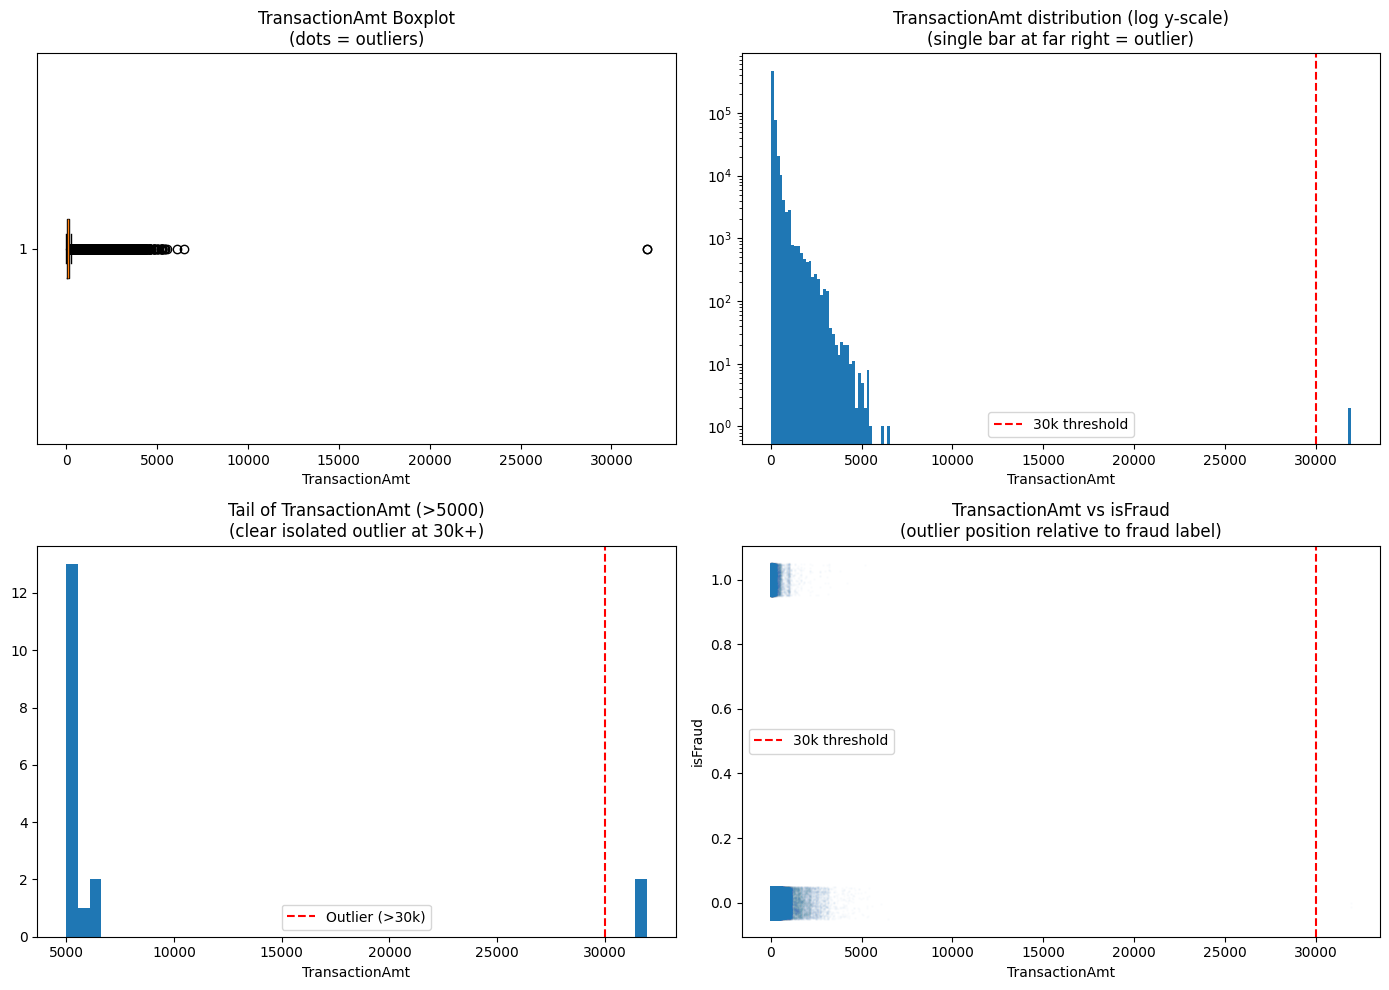

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Box plot — outliers show up clearly as dots
axes[0, 0].boxplot(df['TransactionAmt'].dropna(), vert=False)
axes[0, 0].set_title('TransactionAmt Boxplot\n(dots = outliers)')
axes[0, 0].set_xlabel('TransactionAmt')

# 2. Log scale histogram — outlier visible at far right
axes[0, 1].hist(df['TransactionAmt'], bins=200)
axes[0, 1].set_yscale('log')
axes[0, 1].axvline(30000, color='red', linestyle='--', label='30k threshold')
axes[0, 1].set_title('TransactionAmt distribution (log y-scale)\n(single bar at far right = outlier)')
axes[0, 1].set_xlabel('TransactionAmt')
axes[0, 1].legend()

# 3. Zoom in on the tail — most revealing
tail = df[df['TransactionAmt'] > 5000]['TransactionAmt']
axes[1, 0].hist(tail, bins=50)
axes[1, 0].axvline(30000, color='red', linestyle='--', label='Outlier (>30k)')
axes[1, 0].set_title('Tail of TransactionAmt (>5000)\n(clear isolated outlier at 30k+)')
axes[1, 0].set_xlabel('TransactionAmt')
axes[1, 0].legend()

# 4. Scatter — show outlier vs fraud label
axes[1, 1].scatter(
    df['TransactionAmt'],
    df['isFraud'] + np.random.uniform(-0.05, 0.05, len(df)),  # jitter
    alpha=0.01, s=1
)
axes[1, 1].axvline(30000, color='red', linestyle='--', label='30k threshold')
axes[1, 1].set_title('TransactionAmt vs isFraud\n(outlier position relative to fraud label)')
axes[1, 1].set_xlabel('TransactionAmt')
axes[1, 1].set_ylabel('isFraud')
axes[1, 1].legend()

plt.tight_layout()

# Time Features

/tmp/ipykernel_57/3448530906.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['datetime']  = START_DATE + pd.to_timedelta(train_df['TransactionDT'], unit='s')
/tmp/ipykernel_57/3448530906.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['hour']      = train_df['datetime'].dt.hour
/tmp/ipykernel_57/3448530906.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

Text(0.5, 1.0, 'Fraud rate by day of week')

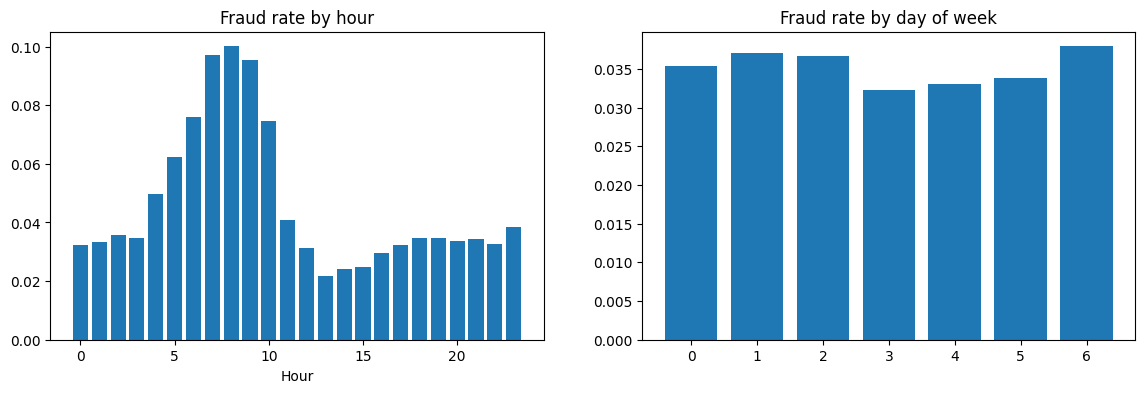

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

START_DATE = pd.Timestamp('2017-01-01')
train_df['datetime']  = START_DATE + pd.to_timedelta(train_df['TransactionDT'], unit='s')
train_df['hour']      = train_df['datetime'].dt.hour
train_df['dayofweek'] = train_df['datetime'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hour_fraud = train_df.groupby('hour')['isFraud'].mean()
axes[0].bar(hour_fraud.index, hour_fraud.values)
axes[0].set_title('Fraud rate by hour')
axes[0].set_xlabel('Hour')

dow_fraud = train_df.groupby('dayofweek')['isFraud'].mean()
axes[1].bar(dow_fraud.index, dow_fraud.values)
axes[1].set_title('Fraud rate by day of week')

# 'TransactionAmt' Column

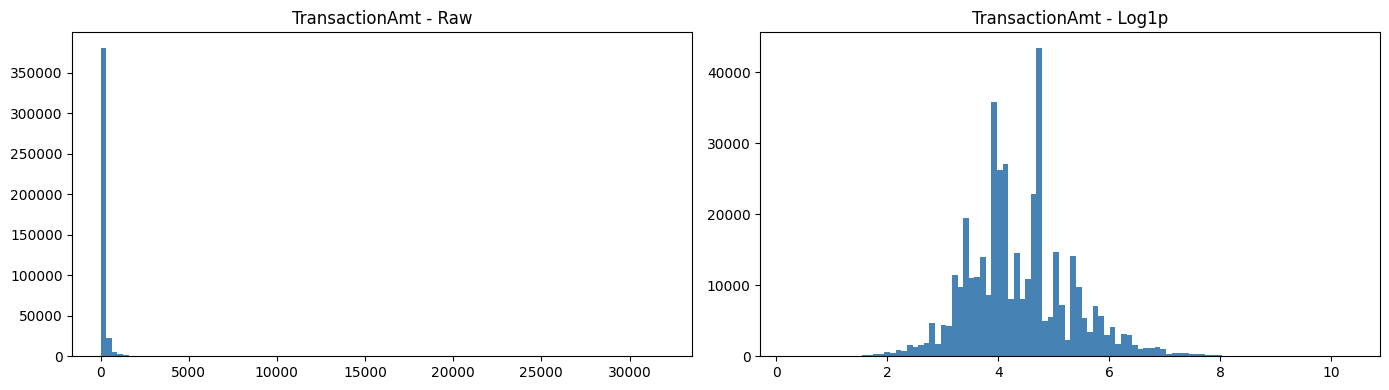

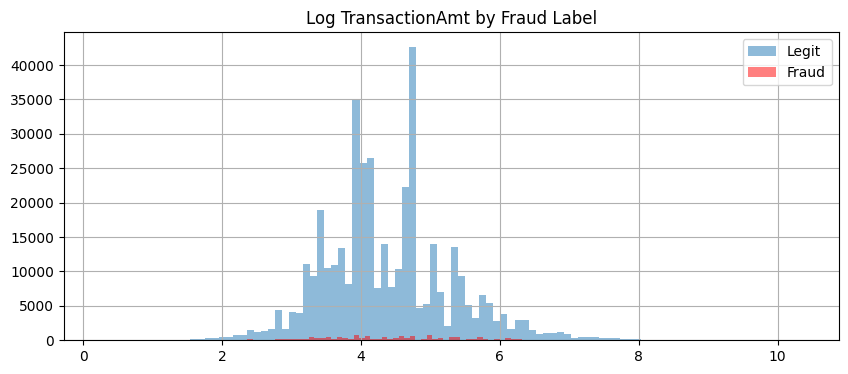

In [20]:
import matplotlib.pyplot as plt
import numpy as np

eda_df = train_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(eda_df['TransactionAmt'], bins=100, color='steelblue')
axes[0].set_title('TransactionAmt - Raw')

axes[1].hist(np.log1p(eda_df['TransactionAmt']), bins=100, color='steelblue')
axes[1].set_title('TransactionAmt - Log1p')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
eda_df[eda_df['isFraud']==0]['TransactionAmt'].apply(np.log1p).hist(bins=100, alpha=0.5, label='Legit', ax=ax)
eda_df[eda_df['isFraud']==1]['TransactionAmt'].apply(np.log1p).hist(bins=100, alpha=0.5, label='Fraud', ax=ax, color='red')
ax.set_title('Log TransactionAmt by Fraud Label')
ax.legend()
plt.show()

# Vesta Columns

In [21]:
v_cols = [col for col in train_df.columns if col.startswith('V')]

groups = {}

for col in v_cols:
    na_count = train_df[col].isna().sum()

    if na_count not in groups:
        groups[na_count] = []

    groups[na_count].append(col)

for na_count, cols in groups.items():
    print('------')
    print(f'Number of NA: {na_count}')
    print(f'Percantage of V columns: {(len(cols) / len(v_cols)) * 100}%')

------
Number of NA: 225773
Percantage of V columns: 3.2448377581120944%
------
Number of NA: 61214
Percantage of V columns: 6.784660766961652%
------
Number of NA: 122244
Percantage of V columns: 5.3097345132743365%
------
Number of NA: 62551
Percantage of V columns: 6.489675516224189%
------
Number of NA: 68356
Percantage of V columns: 5.899705014749262%
------
Number of NA: 0
Percantage of V columns: 12.684365781710916%
------
Number of NA: 348208
Percantage of V columns: 8.55457227138643%
------
Number of NA: 306809
Percantage of V columns: 9.144542772861357%
------
Number of NA: 306798
Percantage of V columns: 5.604719764011799%
------
Number of NA: 312530
Percantage of V columns: 13.569321533923304%
------
Number of NA: 305243
Percantage of V columns: 4.71976401179941%
------
Number of NA: 12
Percantage of V columns: 9.43952802359882%
------
Number of NA: 273
Percantage of V columns: 3.2448377581120944%
------
Number of NA: 347917
Percantage of V columns: 5.3097345132743365%


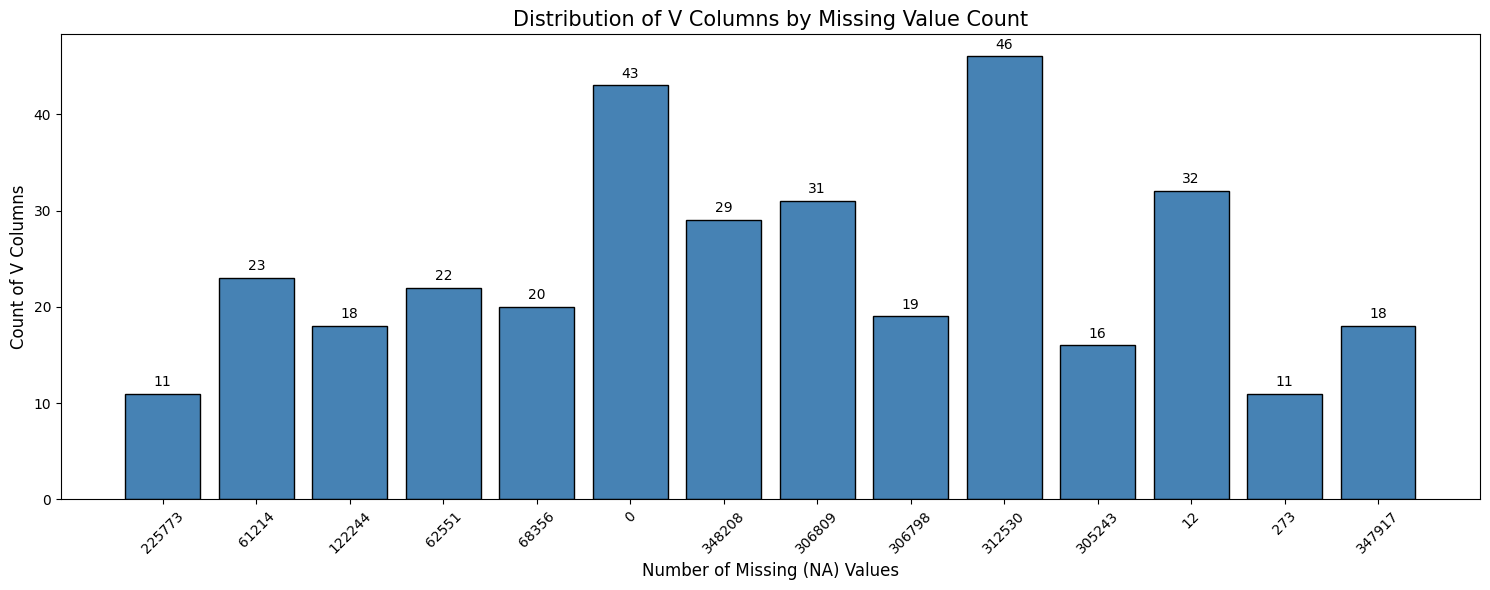

In [22]:
import matplotlib.pyplot as plt

# 1. Prepare data for plotting
# X-axis: Number of missing values (the keys in your 'groups' dict)
# Y-axis: Number of V columns in that group (length of lists in 'groups')
x_data = [str(na_count) for na_count in groups.keys()]
y_data = [len(cols) for cols in groups.values()]

# 2. Create the plot
plt.figure(figsize=(15, 6))
bars = plt.bar(x_data, y_data, color='steelblue', edgecolor='black')

# 3. Add labels and title
plt.title('Distribution of V Columns by Missing Value Count', fontsize=15)
plt.xlabel('Number of Missing (NA) Values', fontsize=12)
plt.ylabel('Count of V Columns', fontsize=12)
plt.xticks(rotation=45)

# 4. Add data labels on top of bars for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.tight_layout()
plt.show()

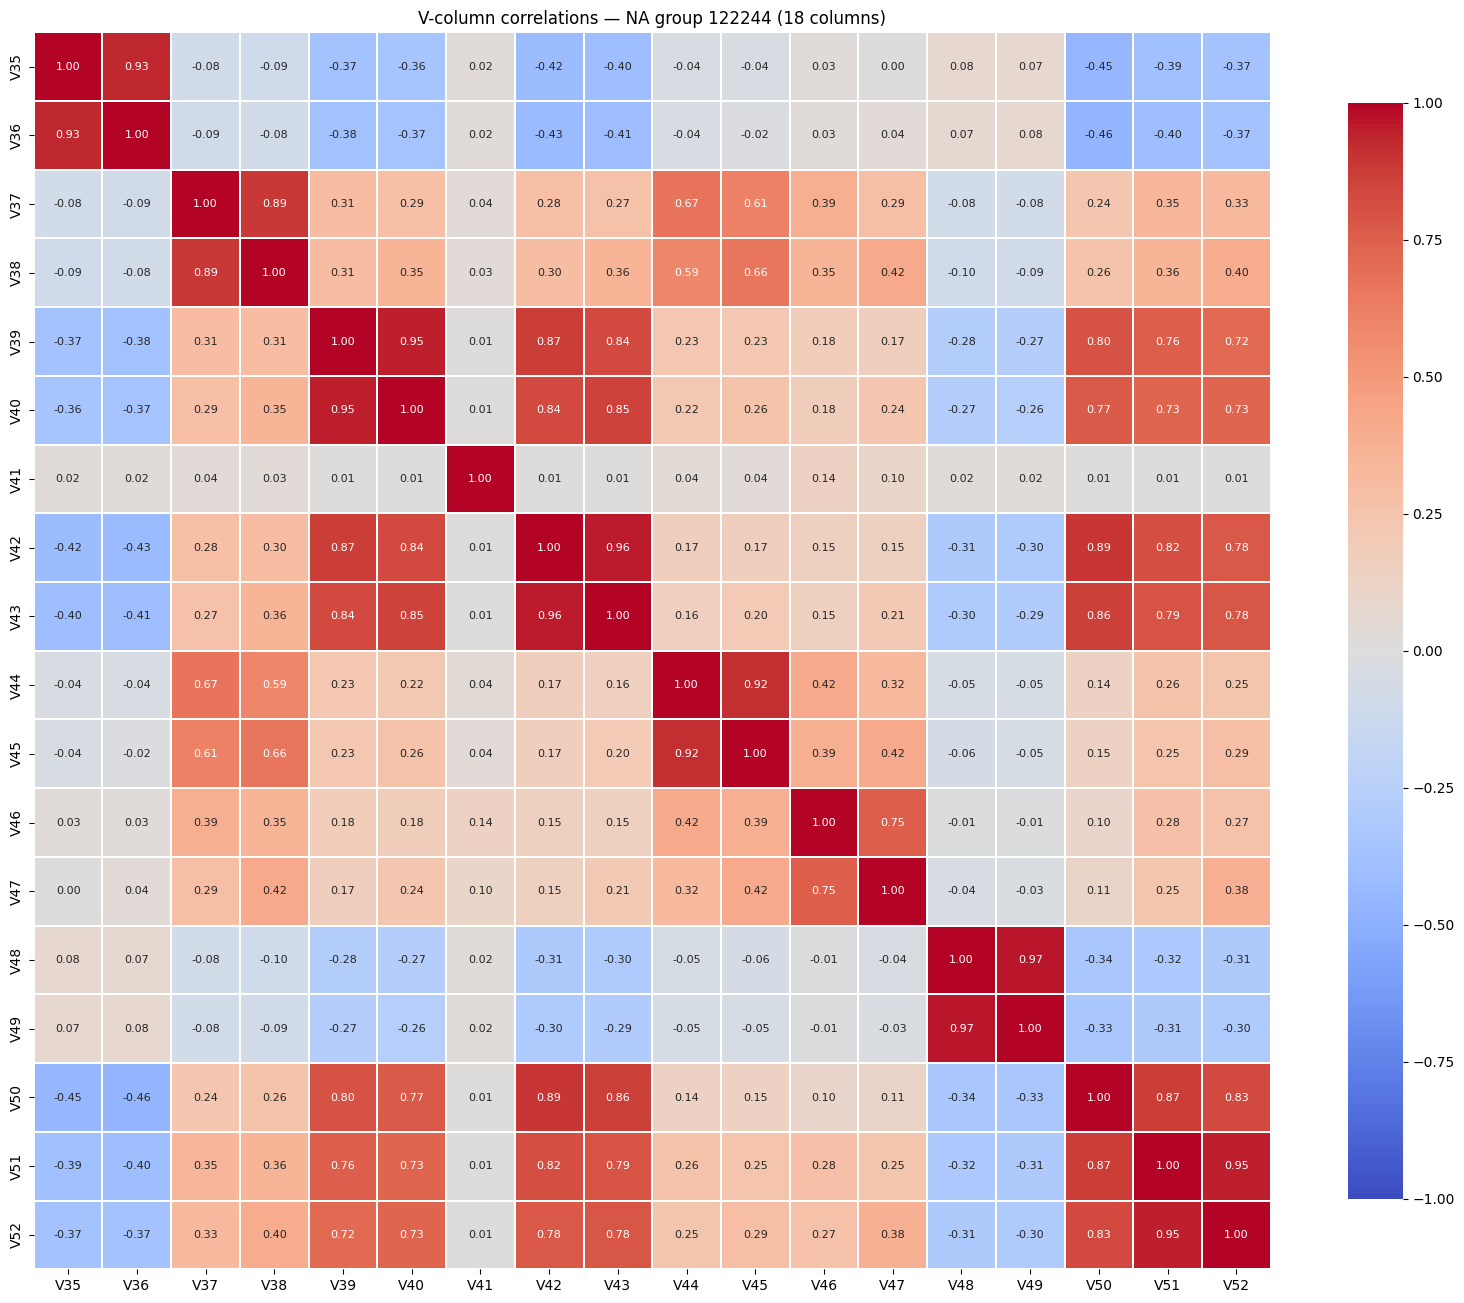

In [23]:
def compute_group_correlation(df, cols):
    filled = df[cols].fillna(df[cols].mean())
    return filled.corr()

group_cols = groups[122244]

corr_matrix = compute_group_correlation(train_df, group_cols)

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)

plt.title(f'V-column correlations — NA group 122244 ({len(group_cols)} columns)')
plt.tight_layout()
plt.show()

# Cardinality Of Categorical Columns

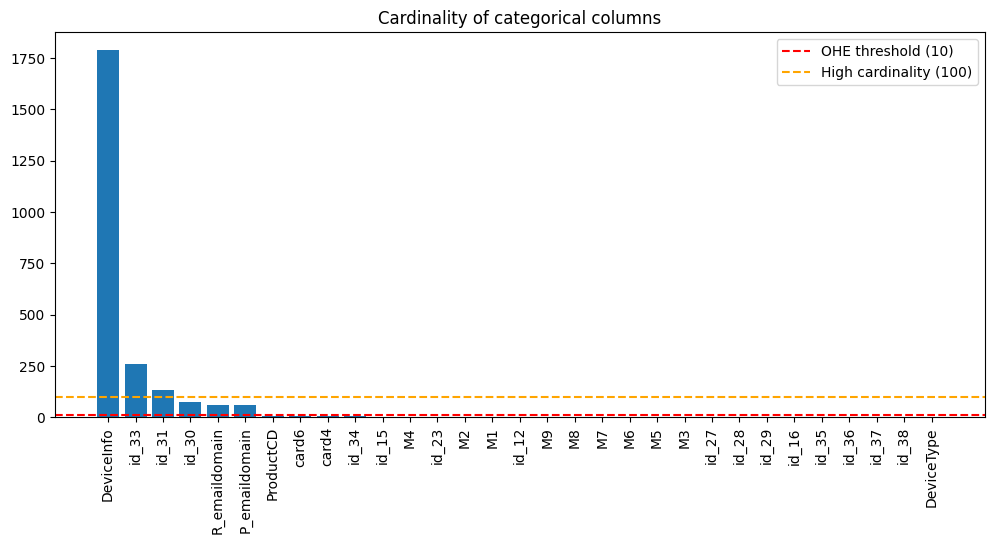

In [24]:
cat_cols = df.select_dtypes(include='object').columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(cardinality)), cardinality.values)
ax.set_xticks(range(len(cardinality)))
ax.set_xticklabels(cardinality.index, rotation=90)
ax.axhline(10, color='red', linestyle='--', label='OHE threshold (10)')
ax.axhline(100, color='orange', linestyle='--', label='High cardinality (100)')
ax.set_title('Cardinality of categorical columns')
ax.legend()

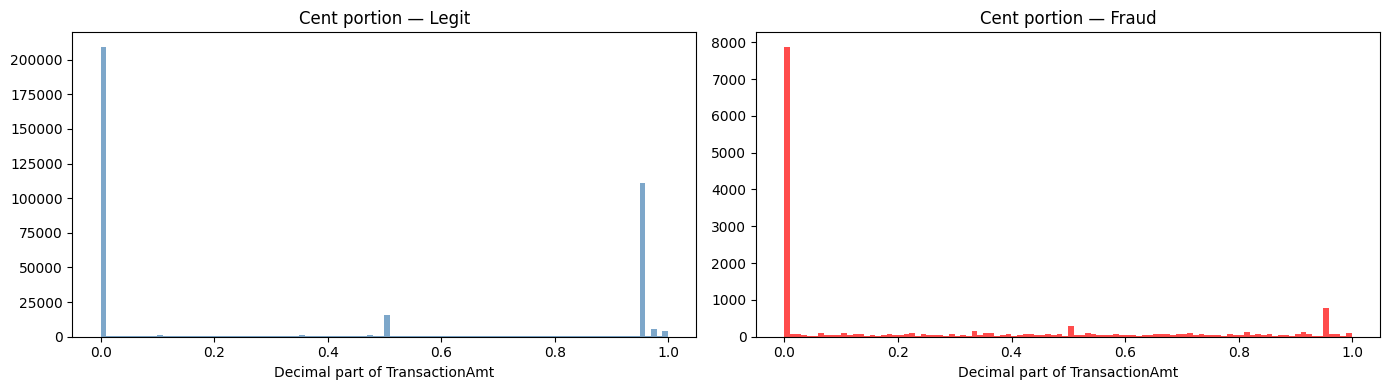

Legit round numbers: 52.4%
Fraud round numbers: 53.8%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Legit
axes[0].hist(train_df[train_df['isFraud']==0]['TransactionAmt'] % 1, 
             bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Cent portion — Legit')
axes[0].set_xlabel('Decimal part of TransactionAmt')

# Fraud
axes[1].hist(train_df[train_df['isFraud']==1]['TransactionAmt'] % 1, 
             bins=100, color='red', alpha=0.7)
axes[1].set_title('Cent portion — Fraud')
axes[1].set_xlabel('Decimal part of TransactionAmt')

plt.tight_layout()
plt.show()

# also print what % of each class uses round numbers
legit_round = (train_df[train_df['isFraud']==0]['TransactionAmt'] % 1 == 0).mean()
fraud_round = (train_df[train_df['isFraud']==1]['TransactionAmt'] % 1 == 0).mean()
print(f'Legit round numbers: {legit_round:.1%}')
print(f'Fraud round numbers: {fraud_round:.1%}')

# UID

/tmp/ipykernel_57/3837523540.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['D1n'] = train_df['D1'] - train_df['TransactionDT'] / (24 * 60 * 60)
/tmp/ipykernel_57/3837523540.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['uid'] = train_df['card1'].astype(str) + '_' + \


train_df rows: 413378
uid rows: 183309


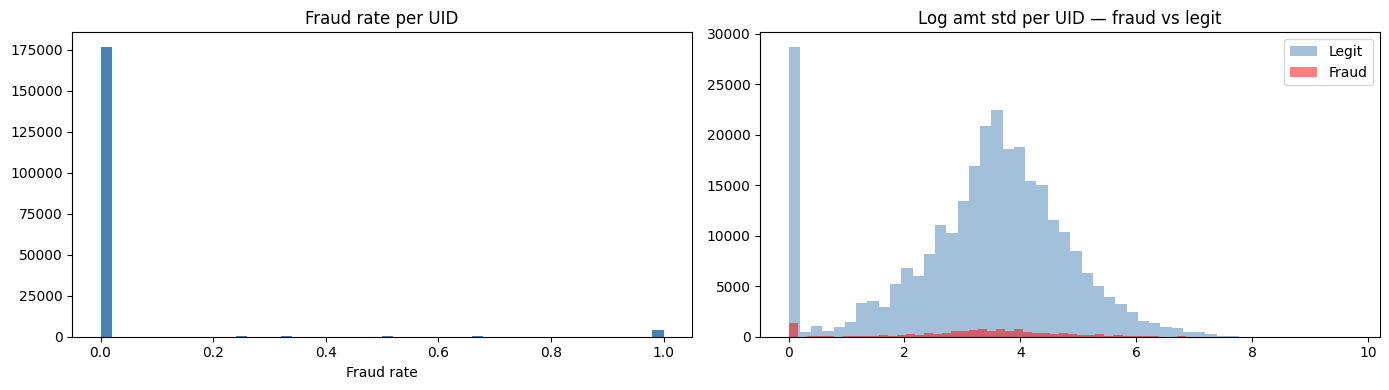

UIDs that are 100% fraud:  2.2%
UIDs that are 100% legit:  96.4%
UIDs with mixed behavior:  1.4%


In [26]:
# Build uid on eda_df to visualize
train_df['D1n'] = train_df['D1'] - train_df['TransactionDT'] / (24 * 60 * 60)
train_df['uid'] = train_df['card1'].astype(str) + '_' + \
                train_df['addr1'].astype(str) + '_' + \
                train_df['D1n'].round(0).astype(str)

# How many transactions per uid?
uid_counts = train_df.groupby('uid')['isFraud'].agg(['count', 'mean'])
uid_counts.columns = ['txn_count', 'fraud_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

print('train_df rows:', len(train_df))
print('uid rows:', len(uid_counts))


# Plot 1 — fraud rate distribution per uid
axes[0].hist(uid_counts['fraud_rate'], bins=50, color='steelblue')
axes[0].set_title('Fraud rate per UID')
axes[0].set_xlabel('Fraud rate')

# Plot 2 — amt std per uid, split by fraud
uid_amt = train_df.groupby('uid')['TransactionAmt'].std().reset_index()
uid_amt.columns = ['uid', 'amt_std']
merged = train_df[['uid', 'isFraud']].merge(uid_amt, on='uid')

axes[1].hist(np.log1p(merged[merged['isFraud']==0]['amt_std'].dropna()), 
             bins=50, alpha=0.5, color='steelblue', label='Legit')
axes[1].hist(np.log1p(merged[merged['isFraud']==1]['amt_std'].dropna()), 
             bins=50, alpha=0.5, color='red', label='Fraud')
axes[1].set_title('Log amt std per UID — fraud vs legit')
axes[1].legend()

plt.tight_layout()
plt.show()

# Key stat — what % of uids are 100% fraud?
all_fraud = (uid_counts['fraud_rate'] == 1.0).mean()
all_legit = (uid_counts['fraud_rate'] == 0.0).mean()
print(f'UIDs that are 100% fraud:  {all_fraud:.1%}')
print(f'UIDs that are 100% legit:  {all_legit:.1%}')
print(f'UIDs with mixed behavior:  {1-all_fraud-all_legit:.1%}')

In [27]:
D1n = train_df['D1'] - train_df['TransactionDT'] / (24 * 60 * 60)
uid = train_df['card1'].astype(str) + '_' + \
      train_df['addr1'].astype(str) + '_' + \
      D1n.round(0).astype(str)

uid_counts = uid.value_counts()
print(f'Total UIDs:              {uid_counts.shape[0]}')
print(f'UIDs with 1 transaction: {(uid_counts == 1).sum()} ({(uid_counts == 1).mean():.1%})')
print(f'UIDs with 2+:            {(uid_counts > 1).sum()} ({(uid_counts > 1).mean():.1%})')
print(f'UIDs with 5+:            {(uid_counts >= 5).sum()}')
print(f'\nuid_counts:\n{uid_counts.describe()}')

Total UIDs:              183309
UIDs with 1 transaction: 111569 (60.9%)
UIDs with 2+:            71740 (39.1%)
UIDs with 5+:            17928

uid_counts:
count    183309.000000
mean          2.255088
std           3.451727
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         253.000000
Name: count, dtype: float64


In [28]:
uid2 = train_df['card1'].astype(str) + '_' + train_df['addr1'].astype(str)

uid2_counts = uid2.value_counts()
print(f'Total UIDs:              {uid2_counts.shape[0]}')
print(f'UIDs with 1 transaction: {(uid2_counts == 1).sum()} ({(uid2_counts == 1).mean():.1%})')
print(f'UIDs with 2+:            {(uid2_counts > 1).sum()} ({(uid2_counts > 1).mean():.1%})')
print(f'UIDs with 5+:            {(uid2_counts >= 5).sum()}')
print(f'\n{uid2_counts.describe()}')

Total UIDs:              34755
UIDs with 1 transaction: 14230 (40.9%)
UIDs with 2+:            20525 (59.1%)
UIDs with 5+:            10650

count    34755.000000
mean        11.894058
std         79.924743
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       7163.000000
Name: count, dtype: float64


In [29]:
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f'num_cols ({len(num_cols)}): {num_cols}\n')
print(f'cat_cols ({len(cat_cols)}): {cat_cols}\n')

num_cols (402): ['TransactionID', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98

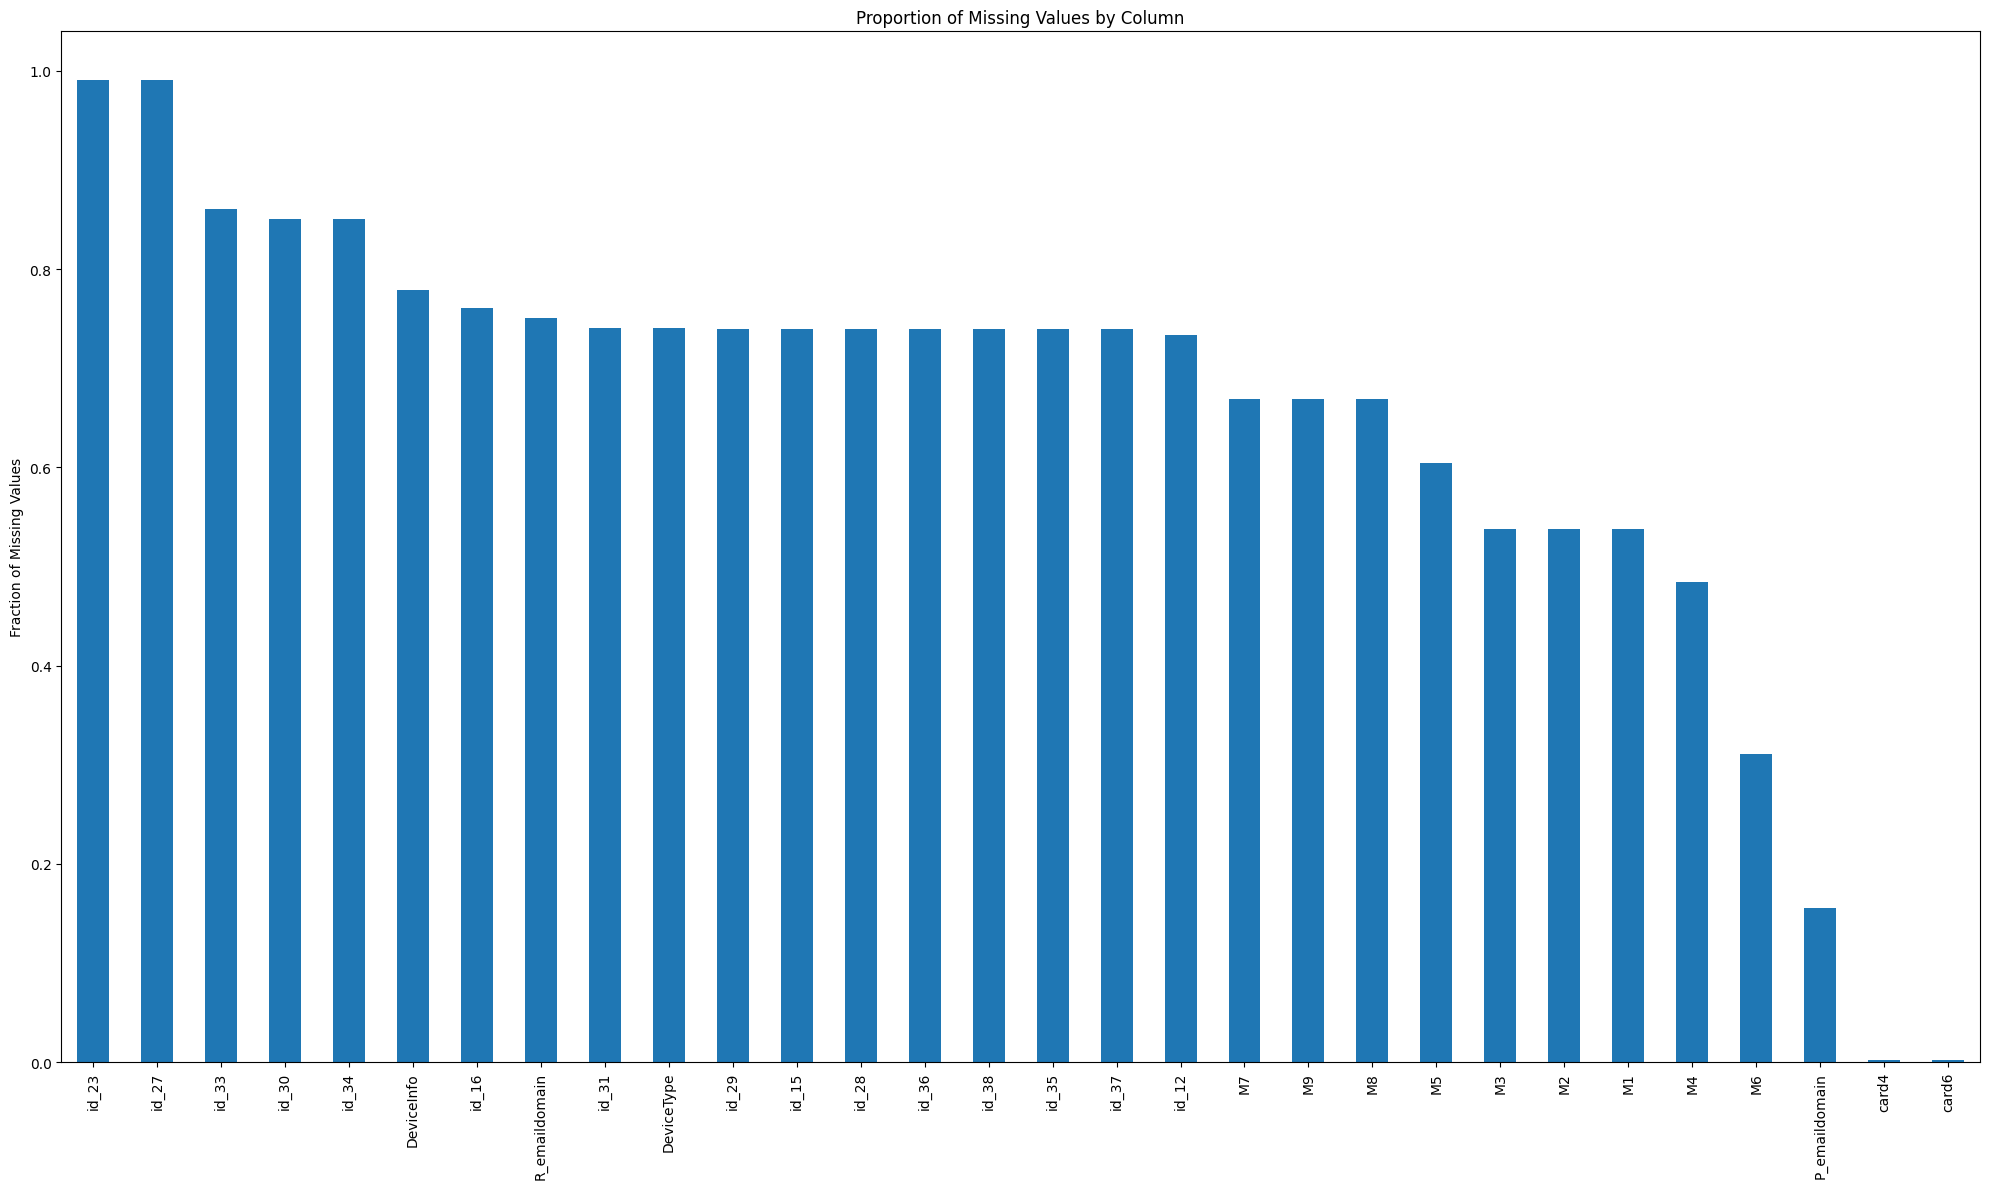

null_ratio (30):
id_23            0.990471
id_27            0.990471
id_33            0.860871
id_30            0.850524
id_34            0.850357
DeviceInfo       0.778987
id_16            0.760669
R_emaildomain    0.750734
id_31            0.740586
DeviceType       0.740197
id_29            0.739841
id_15            0.739841
id_28            0.739841
id_36            0.739841
id_38            0.739841
id_35            0.739841
id_37            0.739841
id_12            0.734115
M7               0.669206
M9               0.669196
M8               0.669196
M5               0.604156
M3               0.538043
M2               0.538043
M1               0.538043
M4               0.484174
M6               0.311219
P_emaildomain    0.155538
card4            0.002005
card6            0.001998
dtype: float64


In [30]:
import matplotlib.pyplot as plt

cat_nan_ratio = X_train[cat_cols].isna().sum() / X_train.shape[0]
cat_nan_ratio_sorted = cat_nan_ratio[cat_nan_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(20, 12))
cat_nan_ratio_sorted.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.tight_layout()
plt.show()

print(f"null_ratio ({len(cat_nan_ratio_sorted)}):\n{cat_nan_ratio_sorted}")

In [31]:
X_train['TransactionAmt'].sort_values(ascending=False)

274336    31937.391
274339    31937.391
296021     6450.970
248413     6085.230
384603     5543.230
            ...    
205370        0.292
205382        0.292
29976         0.292
367961        0.272
374299        0.251
Name: TransactionAmt, Length: 413378, dtype: float64

In [32]:
train_df['TransactionAmt'].value_counts()

TransactionAmt
59.000     20255
117.000    19299
100.000    16608
107.950    15663
57.950     15424
           ...  
196.950        1
71.114         1
682.500        1
685.580        1
524.900        1
Name: count, Length: 15931, dtype: int64

# Train VS Val (Logistic Regression l1)

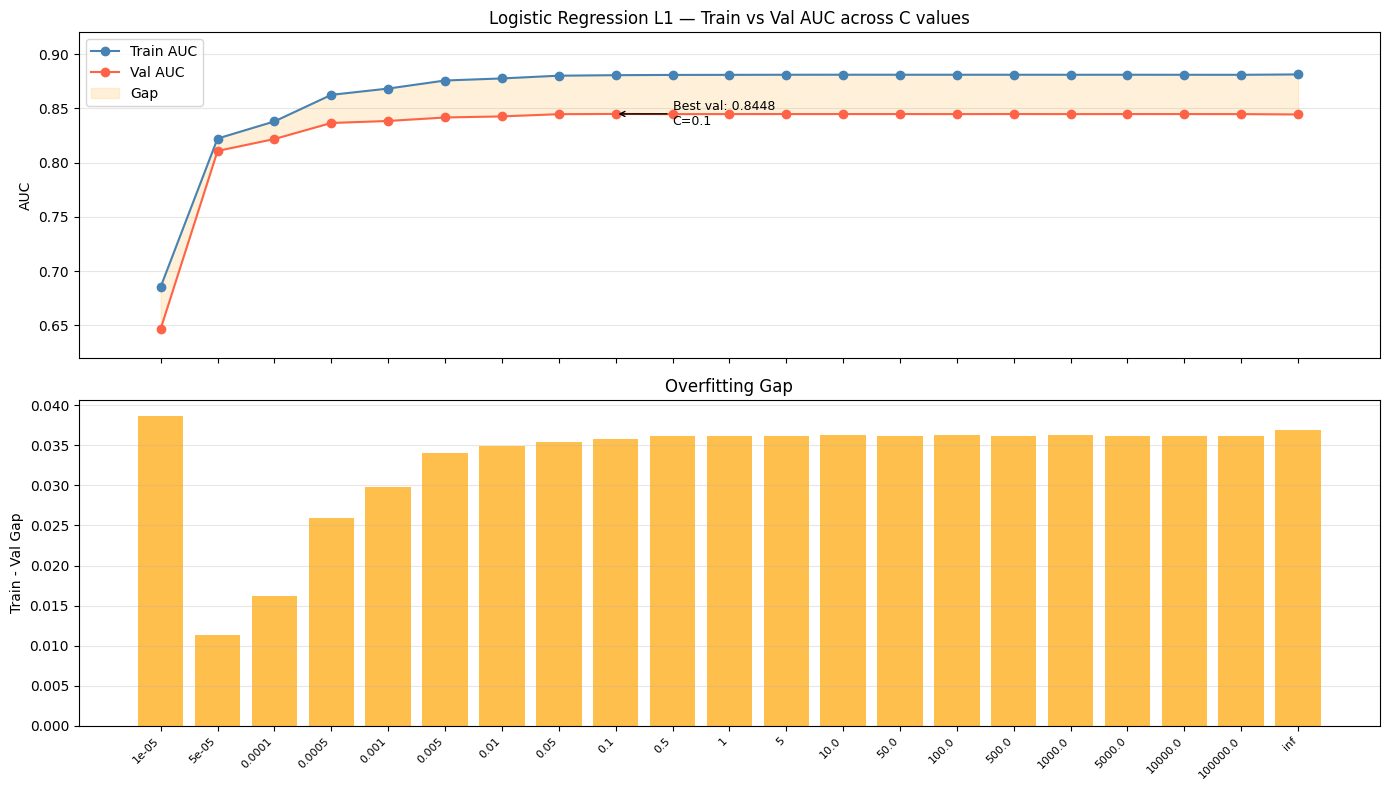

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# results = {
#     1e-5:   (0.685, 0.647),
#     5e-5:   (0.822, 0.811),
#     1e-4:   (0.838, 0.822),
#     5e-4:   (0.862, 0.836),
#     1e-3:   (0.868, 0.838),
#     5e-3:   (0.876, 0.842),
#     1e-2:   (0.878, 0.843),
#     5e-2:   (0.880, 0.845),
#     1e-1:   (0.880, 0.845),
#     5e-1:   (0.881, 0.845),
#     1:      (0.881, 0.845),
#     5:      (0.881, 0.845),
#     10:     (0.881, 0.845),
#     50:     (0.881, 0.845),
#     100:    (0.881, 0.845),
#     500:    (0.881, 0.845),
#     1000:   (0.881, 0.845),
#     5000:   (0.881, 0.845),
#     10000:  (0.881, 0.845),
#     100000: (0.881, 0.845),
#     np.inf: (0.881, 0.844),
# }

results = {
    1e-5:     (0.6856144784209052, 0.6469449452137512),
    5e-5:     (0.8221843058551186, 0.8107915549231116),
    1e-4:     (0.8379505178789295, 0.8217495848481984),
    5e-4:     (0.8624339524295791, 0.8365367696334137),
    1e-3:     (0.8682106713817298, 0.8383850870274068),
    5e-3:     (0.8756375130815118, 0.8415852759458510),
    1e-2:     (0.8775472411746714, 0.8425842281829700),
    5e-2:     (0.8800760770686773, 0.8446373688894644),
    1e-1:     (0.8805517011163437, 0.8448379379398698),
    5e-1:     (0.8807817138335097, 0.8446753305886386),
    1:        (0.8808445827333163, 0.8447262702851921),
    5:        (0.8809359285965619, 0.8447392636547921),
    1e1:      (0.8809695094381493, 0.8447420306545294),
    5e1:      (0.8809454016593092, 0.8447400361088855),
    1e2:      (0.8809454923749916, 0.8447068974439755),
    5e2:      (0.8809423230173943, 0.8447658114800498),
    1e3:      (0.8809248302399149, 0.8446968055810447),
    5e3:      (0.8809384950225512, 0.8447432796474663),
    1e4:      (0.8809148287496942, 0.8447253133644497),
    1e5:      (0.8808923338473982, 0.8446911870343558),
    np.inf:   (0.8812414928178222, 0.8443642198987265),
}

c_vals    = list(results.keys())
train_auc = [v[0] for v in results.values()]
val_auc   = [v[1] for v in results.values()]
gap       = [t - v for t, v in zip(train_auc, val_auc)]

c_labels = [str(c) for c in c_vals]
x = range(len(c_vals))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# top — train vs val AUC
axes[0].plot(x, train_auc, marker='o', color='steelblue', label='Train AUC')
axes[0].plot(x, val_auc,   marker='o', color='tomato',    label='Val AUC')
axes[0].fill_between(x, val_auc, train_auc, alpha=0.15, color='orange', label='Gap')
axes[0].set_ylabel('AUC')
axes[0].set_title('Logistic Regression L1 — Train vs Val AUC across C values')
axes[0].legend()
axes[0].set_ylim(0.62, 0.92)
axes[0].grid(axis='y', alpha=0.3)

# annotate best val
best_idx = val_auc.index(max(val_auc))
axes[0].annotate(f'Best val: {max(val_auc):.4f}\nC={c_labels[best_idx]}',
                 xy=(best_idx, max(val_auc)),
                 xytext=(best_idx + 1, max(val_auc) - 0.01),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

# bottom — train/val gap
axes[1].bar(x, gap, color='orange', alpha=0.7)
axes[1].set_ylabel('Train - Val Gap')
axes[1].set_title('Overfitting Gap')
axes[1].set_xticks(x)
axes[1].set_xticklabels(c_labels, rotation=45, ha='right', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

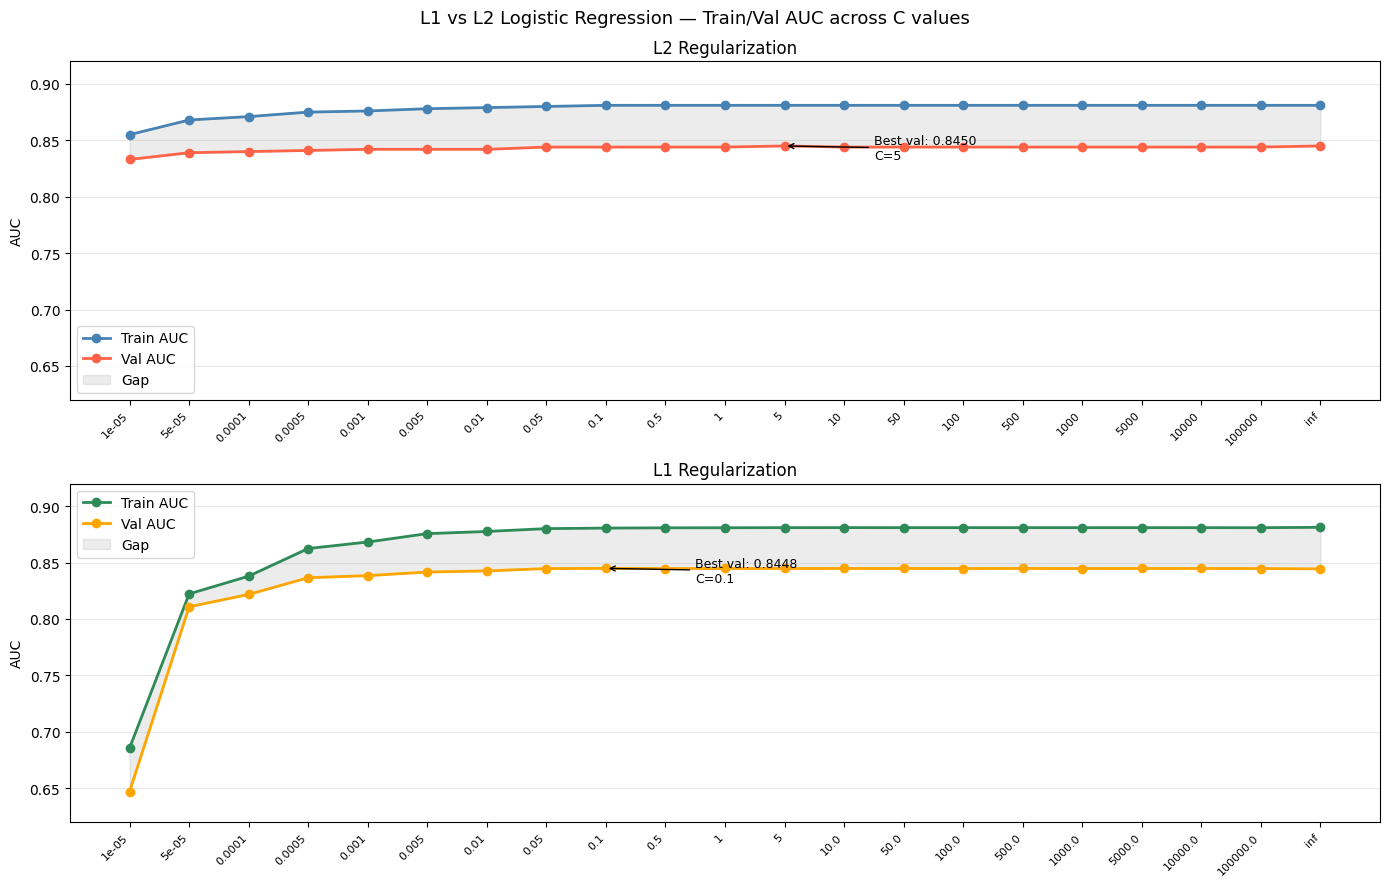

In [34]:
import matplotlib.pyplot as plt
import numpy as np

results_l2 = {
    # 1e-6:   (0.826, 0.816),
    # 5e-6:   (0.846, 0.829),
    1e-5:   (0.855, 0.833),
    5e-5:   (0.868, 0.839),
    1e-4:   (0.871, 0.840),
    5e-4:   (0.875, 0.841),
    1e-3:   (0.876, 0.842),
    5e-3:   (0.878, 0.842),
    1e-2:   (0.879, 0.842),
    5e-2:   (0.880, 0.844),
    1e-1:   (0.881, 0.844),
    5e-1:   (0.881, 0.844),
    1:      (0.881, 0.844),
    5:      (0.881, 0.845),
    10:     (0.881, 0.844),
    50:     (0.881, 0.844),
    100:    (0.881, 0.844),
    500:    (0.881, 0.844),
    1000:   (0.881, 0.844),
    5000:   (0.881, 0.844),
    10000:  (0.881, 0.844),
    100000: (0.881, 0.844),
    np.inf: (0.881, 0.845),
}

results_l1 = {
#     1e-6:     (0.5000000000000000, 0.5000000000000000),
#     5e-6:     (0.5000000000000000, 0.5000000000000000),
    1e-5:     (0.6856144784209052, 0.6469449452137512),
    5e-5:     (0.8221843058551186, 0.8107915549231116),
    1e-4:     (0.8379505178789295, 0.8217495848481984),
    5e-4:     (0.8624339524295791, 0.8365367696334137),
    1e-3:     (0.8682106713817298, 0.8383850870274068),
    5e-3:     (0.8756375130815118, 0.8415852759458510),
    1e-2:     (0.8775472411746714, 0.8425842281829700),
    5e-2:     (0.8800760770686773, 0.8446373688894644),
    1e-1:     (0.8805517011163437, 0.8448379379398698),
    5e-1:     (0.8807817138335097, 0.8446753305886386),
    1:        (0.8808445827333163, 0.8447262702851921),
    5:        (0.8809359285965619, 0.8447392636547921),
    1e1:      (0.8809695094381493, 0.8447420306545294),
    5e1:      (0.8809454016593092, 0.8447400361088855),
    1e2:      (0.8809454923749916, 0.8447068974439755),
    5e2:      (0.8809423230173943, 0.8447658114800498),
    1e3:      (0.8809248302399149, 0.8446968055810447),
    5e3:      (0.8809384950225512, 0.8447432796474663),
    1e4:      (0.8809148287496942, 0.8447253133644497),
    1e5:      (0.8808923338473982, 0.8446911870343558),
    np.inf:   (0.8812414928178222, 0.8443642198987265),
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, results, title, color_train, color_val in zip(
    axes,
    [results_l2, results_l1],
    ['L2 Regularization', 'L1 Regularization'],
    ['steelblue', 'seagreen'],
    ['tomato', 'orange'],
):
    c_vals    = list(results.keys())
    train_auc = [v[0] for v in results.values()]
    val_auc   = [v[1] for v in results.values()]
    x         = range(len(c_vals))
    c_labels  = [str(c) for c in c_vals]

    ax.plot(x, train_auc, marker='o', color=color_train, label='Train AUC', linewidth=2)
    ax.plot(x, val_auc,   marker='o', color=color_val,   label='Val AUC',   linewidth=2)
    ax.fill_between(x, val_auc, train_auc, alpha=0.15, color='gray', label='Gap')

    best_idx = val_auc.index(max(val_auc))
    ax.annotate(
        f'Best val: {max(val_auc):.4f}\nC={c_labels[best_idx]}',
        xy=(best_idx, max(val_auc)),
        xytext=(best_idx + 1.5, max(val_auc) - 0.012),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=9,
    )

    ax.set_title(title)
    ax.set_ylabel('AUC')
    ax.set_xticks(x)
    ax.set_xticklabels(c_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0.62, 0.92)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('L1 vs L2 Logistic Regression — Train/Val AUC across C values', fontsize=13)
plt.tight_layout()
plt.show()

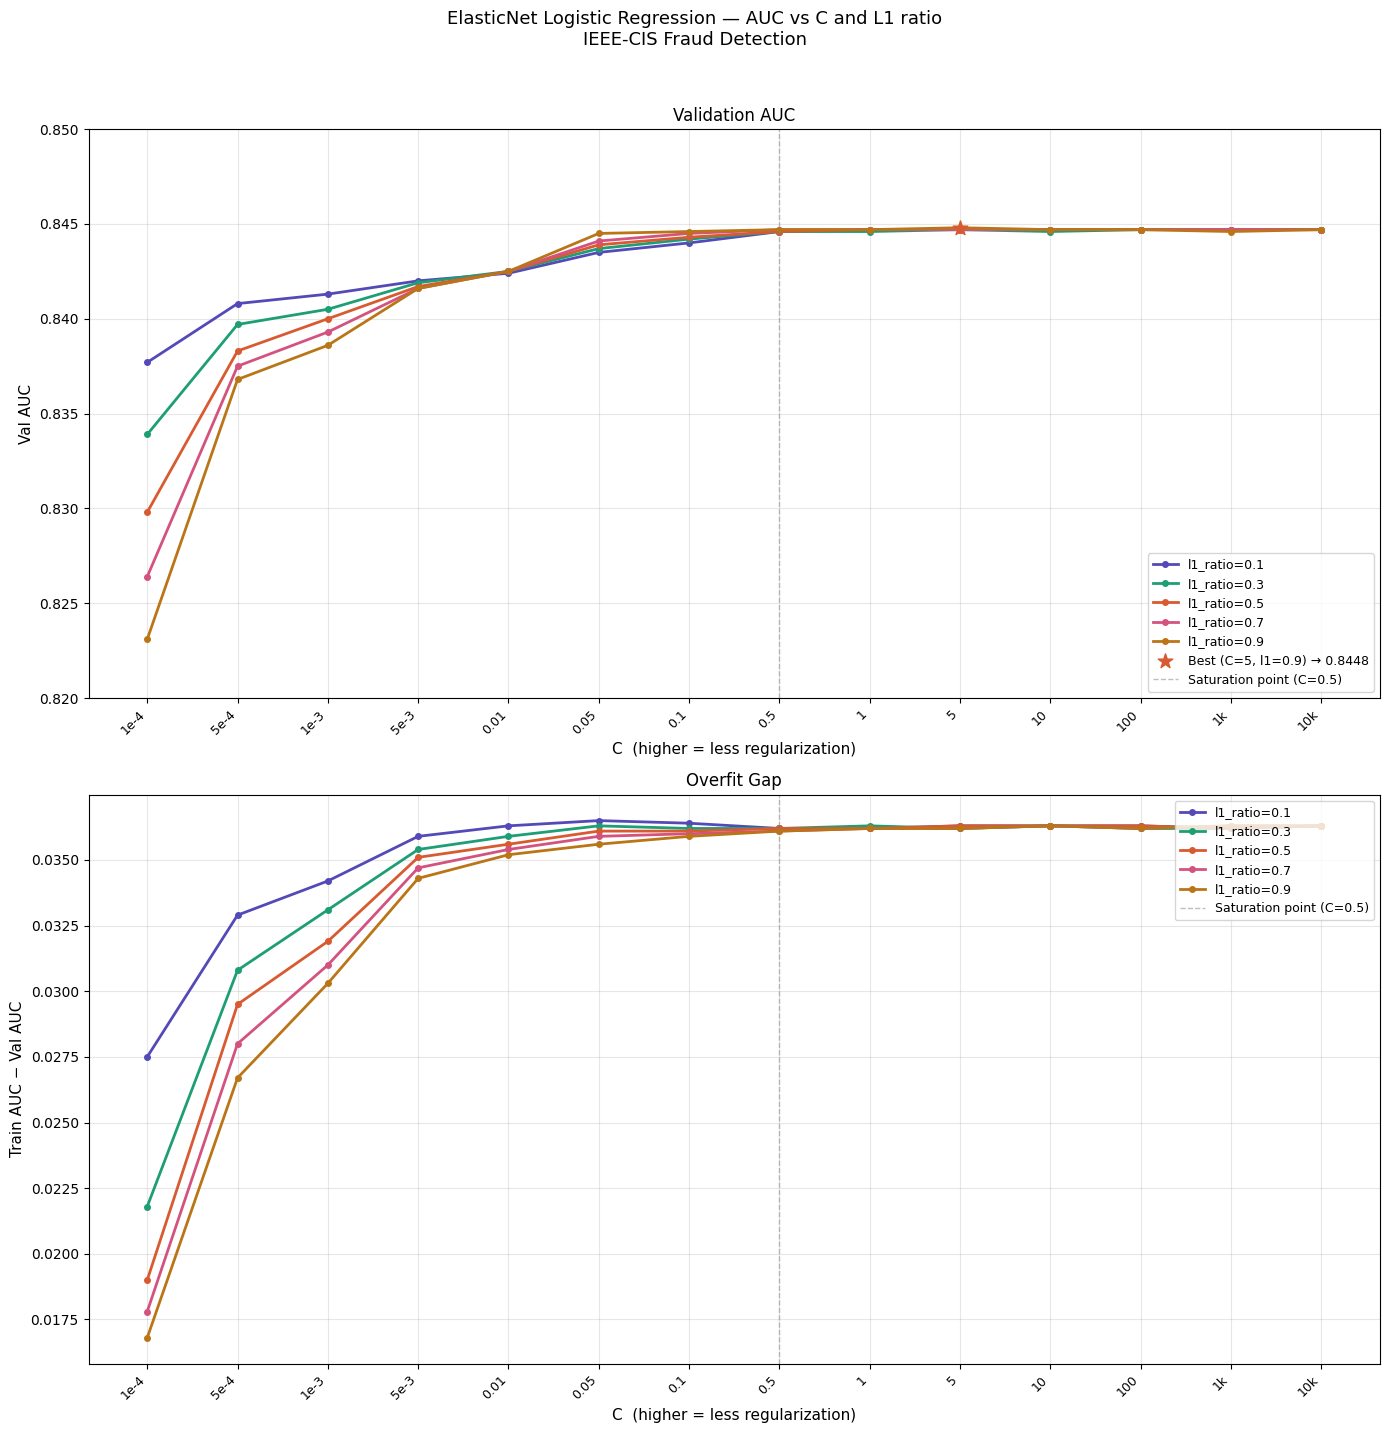

In [35]:
import matplotlib.pyplot as plt
import numpy as np

c_values  = [1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100, 1000, 10000]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

val_aucs = {
    0.1: [0.8377,0.8408,0.8413,0.8420,0.8424,0.8435,0.8440,0.8446,0.8447,0.8447,0.8447,0.8447,0.8447,0.8447],
    0.3: [0.8339,0.8397,0.8405,0.8419,0.8425,0.8437,0.8442,0.8446,0.8446,0.8447,0.8446,0.8447,0.8447,0.8447],
    0.5: [0.8298,0.8383,0.8400,0.8417,0.8425,0.8439,0.8443,0.8446,0.8447,0.8447,0.8447,0.8447,0.8447,0.8447],
    0.7: [0.8264,0.8375,0.8393,0.8416,0.8425,0.8441,0.8445,0.8447,0.8447,0.8447,0.8447,0.8447,0.8447,0.8447],
    0.9: [0.8231,0.8368,0.8386,0.8416,0.8425,0.8445,0.8446,0.8447,0.8447,0.8448,0.8447,0.8447,0.8446,0.8447],
}

train_aucs = {
    0.1: [0.8652,0.8737,0.8755,0.8779,0.8787,0.8800,0.8804,0.8808,0.8809,0.8810,0.8810,0.8810,0.8809,0.8810],
    0.3: [0.8557,0.8705,0.8736,0.8773,0.8784,0.8800,0.8804,0.8808,0.8809,0.8809,0.8809,0.8809,0.8809,0.8810],
    0.5: [0.8488,0.8678,0.8719,0.8768,0.8781,0.8800,0.8804,0.8808,0.8809,0.8810,0.8810,0.8810,0.8809,0.8810],
    0.7: [0.8442,0.8655,0.8703,0.8763,0.8779,0.8800,0.8805,0.8808,0.8809,0.8809,0.8810,0.8809,0.8810,0.8810],
    0.9: [0.8399,0.8635,0.8689,0.8759,0.8777,0.8801,0.8805,0.8808,0.8809,0.8810,0.8810,0.8809,0.8809,0.8810],
}

colors    = ['#534AB7', '#1D9E75', '#D85A30', '#D4537E', '#BA7517']
x_ticks   = ['1e-4','5e-4','1e-3','5e-3','0.01','0.05','0.1','0.5','1','5','10','100','1k','10k']
x_pos     = np.arange(len(c_values))

fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle('ElasticNet Logistic Regression — AUC vs C and L1 ratio\nIEEE-CIS Fraud Detection', 
             fontsize=13, y=1.02)

ax = axes[0]
for i, ratio in enumerate(l1_ratios):
    ax.plot(x_pos, val_aucs[ratio], 
            color=colors[i], marker='o', markersize=4,
            linewidth=2, label=f'l1_ratio={ratio}')

best_val  = 0.8448
best_x    = x_pos[9]  # C=5
ax.scatter([best_x], [best_val], s=120, color='#D85A30', 
           zorder=5, marker='*', label=f'Best (C=5, l1=0.9) → {best_val}')

ax.axvline(x=7, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Saturation point (C=0.5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_ticks, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.820, 0.850)
ax.set_xlabel('C  (higher = less regularization)', fontsize=11)
ax.set_ylabel('Val AUC', fontsize=11)
ax.set_title('Validation AUC', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

ax = axes[1]
for i, ratio in enumerate(l1_ratios):
    gaps = [t - v for t, v in zip(train_aucs[ratio], val_aucs[ratio])]
    ax.plot(x_pos, gaps,
            color=colors[i], marker='o', markersize=4,
            linewidth=2, label=f'l1_ratio={ratio}')

ax.axvline(x=7, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Saturation point (C=0.5)')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_ticks, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('C  (higher = less regularization)', fontsize=11)
ax.set_ylabel('Train AUC − Val AUC', fontsize=11)
ax.set_title('Overfit Gap', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elasticnet_auc_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

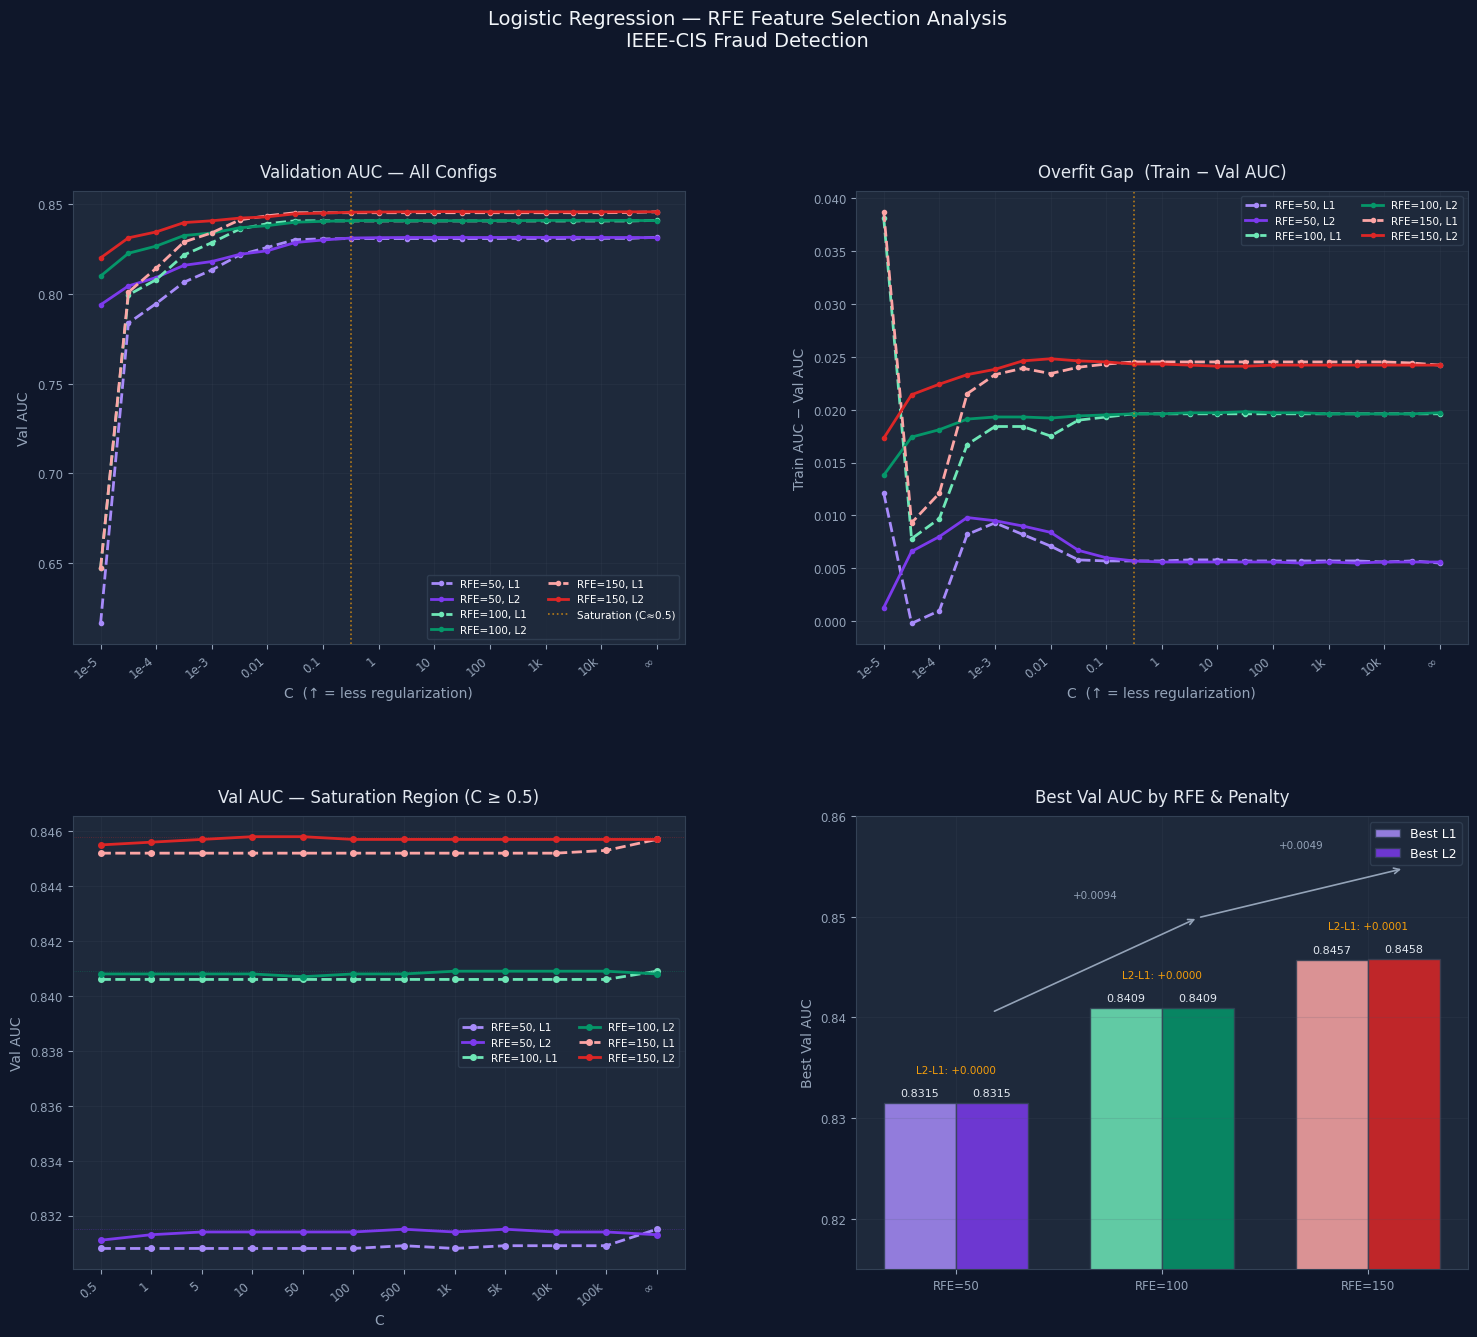

In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Data extracted from training logs ────────────────────────────────────────
C_values = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5,
            1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 100000, np.inf]
x_labels = ['1e-5','5e-5','1e-4','5e-4','1e-3','5e-3','0.01','0.05','0.1',
            '0.5','1','5','10','50','100','500','1k','5k','10k','100k','∞']
x_pos = np.arange(len(C_values))

data = {
    50: {
        'l1': {
            'train': [0.6285,0.7835,0.7956,0.8147,0.8226,0.8299,0.8330,0.8360,0.8363,0.8365,
                      0.8365,0.8366,0.8366,0.8365,0.8365,0.8366,0.8365,0.8366,0.8365,0.8366,0.8370],
            'val':   [0.6164,0.7837,0.7946,0.8065,0.8133,0.8217,0.8259,0.8302,0.8306,0.8308,
                      0.8308,0.8308,0.8308,0.8308,0.8308,0.8309,0.8308,0.8309,0.8309,0.8309,0.8315],
        },
        'l2': {
            'train': [0.7952,0.8110,0.8171,0.8257,0.8275,0.8310,0.8324,0.8353,0.8360,0.8368,
                      0.8369,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8369],
            'val':   [0.7939,0.8044,0.8091,0.8159,0.8180,0.8220,0.8240,0.8286,0.8300,0.8311,
                      0.8313,0.8314,0.8314,0.8314,0.8314,0.8315,0.8314,0.8315,0.8314,0.8314,0.8313],
        },
    },
    100: {
        'l1': {
            'train': [0.6853,0.8072,0.8176,0.8384,0.8469,0.8545,0.8566,0.8597,0.8600,0.8602,
                      0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8605],
            'val':   [0.6472,0.7994,0.8079,0.8217,0.8285,0.8361,0.8391,0.8407,0.8407,0.8406,
                      0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8409],
        },
        'l2': {
            'train': [0.8237,0.8400,0.8447,0.8516,0.8532,0.8561,0.8572,0.8593,0.8599,0.8604,
                      0.8604,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605],
            'val':   [0.8099,0.8226,0.8266,0.8325,0.8339,0.8368,0.8380,0.8399,0.8404,0.8408,
                      0.8408,0.8408,0.8408,0.8407,0.8408,0.8408,0.8409,0.8409,0.8409,0.8409,0.8408],
        },
    },
    150: {
        'l1': {
            'train': [0.6859,0.8102,0.8264,0.8504,0.8573,0.8651,0.8669,0.8692,0.8695,0.8697,
                      0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8699],
            'val':   [0.6472,0.8009,0.8143,0.8289,0.8340,0.8412,0.8435,0.8452,0.8452,0.8452,
                      0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8453,0.8457],
        },
        'l2': {
            'train': [0.8373,0.8526,0.8569,0.8630,0.8645,0.8668,0.8677,0.8692,0.8695,0.8698,
                      0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699],
            'val':   [0.8200,0.8312,0.8345,0.8397,0.8407,0.8422,0.8429,0.8446,0.8450,0.8455,
                      0.8456,0.8457,0.8458,0.8458,0.8457,0.8457,0.8457,0.8457,0.8457,0.8457,0.8457],
        },
    },
}

# ── Style ─────────────────────────────────────────────────────────────────────
palette = {
    (50,  'l1'): '#A78BFA',   # violet-light
    (50,  'l2'): '#7C3AED',   # violet-dark
    (100, 'l1'): '#6EE7B7',   # green-light
    (100, 'l2'): '#059669',   # green-dark
    (150, 'l1'): '#FCA5A5',   # red-light
    (150, 'l2'): '#DC2626',   # red-dark
}
ls_map = {'l1': '--', 'l2': '-'}

SAT_X = 9   # C=0.5, saturation point

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0F172A')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28)

axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]
for ax in axes:
    ax.set_facecolor('#1E293B')
    ax.tick_params(colors='#94A3B8', labelsize=8.5)
    ax.xaxis.label.set_color('#94A3B8')
    ax.yaxis.label.set_color('#94A3B8')
    ax.title.set_color('#E2E8F0')
    for spine in ax.spines.values():
        spine.set_edgecolor('#334155')
    ax.grid(alpha=0.15, color='#475569')

# ── Plot 1: Val AUC all configs ───────────────────────────────────────────────
ax = axes[0]
for n in [50, 100, 150]:
    for p in ['l1', 'l2']:
        label = f'RFE={n}, {p.upper()}'
        ax.plot(x_pos, data[n][p]['val'],
                color=palette[(n, p)], linestyle=ls_map[p],
                linewidth=2, marker='o', markersize=3, label=label)

ax.axvline(SAT_X, color='#F59E0B', linestyle=':', linewidth=1.2, alpha=0.7, label='Saturation (C≈0.5)')
ax.set_xticks(x_pos[::2])
ax.set_xticklabels(x_labels[::2], rotation=40, ha='right')
ax.set_title('Validation AUC — All Configs', fontsize=12, pad=10)
ax.set_ylabel('Val AUC')
ax.set_xlabel('C  (↑ = less regularization)')
ax.legend(fontsize=7.5, loc='lower right', facecolor='#1E293B',
          labelcolor='white', edgecolor='#334155', ncol=2)

# ── Plot 2: Train vs Val gap (overfit) ────────────────────────────────────────
ax = axes[1]
for n in [50, 100, 150]:
    for p in ['l1', 'l2']:
        gap = [t - v for t, v in zip(data[n][p]['train'], data[n][p]['val'])]
        label = f'RFE={n}, {p.upper()}'
        ax.plot(x_pos, gap,
                color=palette[(n, p)], linestyle=ls_map[p],
                linewidth=2, marker='o', markersize=3, label=label)

ax.axvline(SAT_X, color='#F59E0B', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_xticks(x_pos[::2])
ax.set_xticklabels(x_labels[::2], rotation=40, ha='right')
ax.set_title('Overfit Gap  (Train − Val AUC)', fontsize=12, pad=10)
ax.set_ylabel('Train AUC − Val AUC')
ax.set_xlabel('C  (↑ = less regularization)')
ax.legend(fontsize=7.5, loc='upper right', facecolor='#1E293B',
          labelcolor='white', edgecolor='#334155', ncol=2)

# ── Plot 3: Val AUC at saturation — L1 vs L2 per RFE ─────────────────────────
ax = axes[2]
sat_val = {n: {p: data[n][p]['val'][SAT_X:] for p in ['l1','l2']} for n in [50, 100, 150]}
x_sat = x_pos[SAT_X:]
x_sat_labels = x_labels[SAT_X:]

for n in [50, 100, 150]:
    for p in ['l1', 'l2']:
        ax.plot(range(len(x_sat)), sat_val[n][p],
                color=palette[(n, p)], linestyle=ls_map[p],
                linewidth=2, marker='o', markersize=4,
                label=f'RFE={n}, {p.upper()}')

ax.set_xticks(range(len(x_sat)))
ax.set_xticklabels(x_sat_labels, rotation=40, ha='right')
ax.set_title('Val AUC — Saturation Region (C ≥ 0.5)', fontsize=12, pad=10)
ax.set_ylabel('Val AUC')
ax.set_xlabel('C')
ax.legend(fontsize=7.5, facecolor='#1E293B', labelcolor='white',
          edgecolor='#334155', ncol=2)
# annotate best per RFE
best_annotations = {50: 0.8315, 100: 0.8409, 150: 0.8458}
for n, best in best_annotations.items():
    ax.axhline(best, color=palette[(n, 'l2')], linewidth=0.6, alpha=0.4, linestyle=':')

# ── Plot 4: Best val AUC per RFE bar chart ────────────────────────────────────
ax = axes[3]
rfe_vals = [50, 100, 150]
best_l1 = [max(data[n]['l1']['val']) for n in rfe_vals]
best_l2 = [max(data[n]['l2']['val']) for n in rfe_vals]

w = 0.35
xb = np.arange(3)
bars_l1 = ax.bar(xb - w/2, best_l1, width=w, color=['#A78BFA','#6EE7B7','#FCA5A5'],
                 label='Best L1', alpha=0.85, edgecolor='#334155')
bars_l2 = ax.bar(xb + w/2, best_l2, width=w, color=['#7C3AED','#059669','#DC2626'],
                 label='Best L2', alpha=0.85, edgecolor='#334155')

for bar, val in zip(list(bars_l1) + list(bars_l2), best_l1 + best_l2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8, color='#E2E8F0')

# annotate gain
for i, (l1v, l2v) in enumerate(zip(best_l1, best_l2)):
    gain = l2v - l1v
    ax.text(i, max(l1v, l2v) + 0.003, f'L2-L1: +{gain:.4f}',
            ha='center', fontsize=7.5, color='#F59E0B')

ax.set_xticks(xb)
ax.set_xticklabels([f'RFE={n}' for n in rfe_vals])
ax.set_ylim(0.815, 0.860)
ax.set_title('Best Val AUC by RFE & Penalty', fontsize=12, pad=10)
ax.set_ylabel('Best Val AUC')
ax.legend(fontsize=9, facecolor='#1E293B', labelcolor='white', edgecolor='#334155')

# ── Add gain annotations between RFE groups ──────────────────────────────────
for i in range(len(rfe_vals) - 1):
    gain = best_l2[i+1] - best_l2[i]
    ax.annotate('', xy=(i+1+w/2, best_l2[i+1]+0.009),
                xytext=(i+w/2, best_l2[i]+0.009),
                arrowprops=dict(arrowstyle='->', color='#94A3B8', lw=1.2))
    ax.text(i + 0.5 + w/2, best_l2[max(i, i+1)] + 0.011,
            f'+{gain:.4f}', ha='center', fontsize=7.5, color='#94A3B8')

fig.suptitle('Logistic Regression — RFE Feature Selection Analysis\nIEEE-CIS Fraud Detection',
             fontsize=14, color='#F1F5F9', y=1.01)

plt.savefig('lr_rfe_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [37]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np

# # ── Data ─────────────────────────────────────────────────────────────────────
# C_values = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5,
#             1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 100000, np.inf]
# x_labels = ['1e-5','5e-5','1e-4','5e-4','1e-3','5e-3','0.01','0.05','0.1',
#             '0.5','1','5','10','50','100','500','1k','5k','10k','100k','∞']
# x_pos = np.arange(len(C_values))

# data = {
#     50: {
#         'l1': {
#             'train': [0.6285,0.7835,0.7956,0.8147,0.8226,0.8299,0.8330,0.8360,0.8363,0.8365,
#                       0.8365,0.8366,0.8366,0.8365,0.8365,0.8366,0.8365,0.8366,0.8365,0.8366,0.8370],
#             'val':   [0.6164,0.7837,0.7946,0.8065,0.8133,0.8217,0.8259,0.8302,0.8306,0.8308,
#                       0.8308,0.8308,0.8308,0.8308,0.8308,0.8309,0.8308,0.8309,0.8309,0.8309,0.8315],
#         },
#         'l2': {
#             'train': [0.7952,0.8110,0.8171,0.8257,0.8275,0.8310,0.8324,0.8353,0.8360,0.8368,
#                       0.8369,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8369],
#             'val':   [0.7939,0.8044,0.8091,0.8159,0.8180,0.8220,0.8240,0.8286,0.8300,0.8311,
#                       0.8313,0.8314,0.8314,0.8314,0.8314,0.8315,0.8314,0.8315,0.8314,0.8314,0.8313],
#         },
#     },
#     100: {
#         'l1': {
#             'train': [0.6853,0.8072,0.8176,0.8384,0.8469,0.8545,0.8566,0.8597,0.8600,0.8602,
#                       0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8605],
#             'val':   [0.6472,0.7994,0.8079,0.8217,0.8285,0.8361,0.8391,0.8407,0.8407,0.8406,
#                       0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8409],
#         },
#         'l2': {
#             'train': [0.8237,0.8400,0.8447,0.8516,0.8532,0.8561,0.8572,0.8593,0.8599,0.8604,
#                       0.8604,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605],
#             'val':   [0.8099,0.8226,0.8266,0.8325,0.8339,0.8368,0.8380,0.8399,0.8404,0.8408,
#                       0.8408,0.8408,0.8408,0.8407,0.8408,0.8408,0.8409,0.8409,0.8409,0.8409,0.8408],
#         },
#     },
#     150: {
#         'l1': {
#             'train': [0.6859,0.8102,0.8264,0.8504,0.8573,0.8651,0.8669,0.8692,0.8695,0.8697,
#                       0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8699],
#             'val':   [0.6472,0.8009,0.8143,0.8289,0.8340,0.8412,0.8435,0.8452,0.8452,0.8452,
#                       0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8453,0.8457],
#         },
#         'l2': {
#             'train': [0.8373,0.8526,0.8569,0.8630,0.8645,0.8668,0.8677,0.8692,0.8695,0.8698,
#                       0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699],
#             'val':   [0.8200,0.8312,0.8345,0.8397,0.8407,0.8422,0.8429,0.8446,0.8450,0.8455,
#                       0.8456,0.8457,0.8458,0.8458,0.8457,0.8457,0.8457,0.8457,0.8457,0.8457,0.8457],
#         },
#     },
#     200: {
#         'l1': {
#             'train': [0.6876,0.8172,0.8310,0.8537,0.8601,0.8676,0.8694,0.8717,0.8721,0.8724,
#                       0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8726],
#             'val':   [0.6469,0.8080,0.8204,0.8334,0.8356,0.8401,0.8415,0.8428,0.8430,0.8430,
#                       0.8429,0.8429,0.8429,0.8429,0.8430,0.8430,0.8429,0.8428,0.8430,0.8430,0.8433],
#         },
#         'l2': {
#             'train': [0.8425,0.8575,0.8613,0.8663,0.8675,0.8695,0.8702,0.8717,0.8721,0.8725,
#                       0.8725,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726],
#             'val':   [0.8253,0.8347,0.8370,0.8395,0.8397,0.8402,0.8405,0.8422,0.8427,0.8432,
#                       0.8432,0.8433,0.8433,0.8433,0.8433,0.8434,0.8433,0.8434,0.8434,0.8433,0.8441],
#         },
#     },
#     250: {
#         'l1': {
#             'train': [0.6873,0.8181,0.8317,0.8571,0.8634,0.8715,0.8732,0.8757,0.8762,0.8765,
#                       0.8765,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8768],
#             'val':   [0.6469,0.8087,0.8175,0.8329,0.8352,0.8407,0.8419,0.8439,0.8442,0.8441,
#                       0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8439],
#         },
#         'l2': {
#             'train': [0.8473,0.8619,0.8655,0.8704,0.8716,0.8737,0.8745,0.8759,0.8762,0.8767,
#                       0.8767,0.8768,0.8768,0.8768,0.8767,0.8768,0.8768,0.8768,0.8768,0.8768,0.8768],
#             'val':   [0.8265,0.8355,0.8377,0.8402,0.8405,0.8410,0.8415,0.8431,0.8437,0.8439,
#                       0.8440,0.8441,0.8441,0.8441,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8441],
#         },
#     },
# }

# # ── Style ─────────────────────────────────────────────────────────────────────
# rfe_list = [50, 100, 150, 200, 250]
# palette = {
#     (50,  'l1'): '#A78BFA', (50,  'l2'): '#7C3AED',
#     (100, 'l1'): '#6EE7B7', (100, 'l2'): '#059669',
#     (150, 'l1'): '#FCA5A5', (150, 'l2'): '#DC2626',
#     (200, 'l1'): '#FCD34D', (200, 'l2'): '#D97706',
#     (250, 'l1'): '#7DD3FC', (250, 'l2'): '#0369A1',
# }
# ls_map = {'l1': '--', 'l2': '-'}
# SAT_X = 9  # C=0.5

# BG_DARK  = '#0F172A'
# BG_PANEL = '#1E293B'
# C_TICK   = '#94A3B8'
# C_TITLE  = '#E2E8F0'
# C_GRID   = '#475569'
# C_SPINE  = '#334155'
# C_SAT    = '#F59E0B'

# def style_ax(ax):
#     ax.set_facecolor(BG_PANEL)
#     ax.tick_params(colors=C_TICK, labelsize=8.5)
#     ax.xaxis.label.set_color(C_TICK)
#     ax.yaxis.label.set_color(C_TICK)
#     ax.title.set_color(C_TITLE)
#     for spine in ax.spines.values():
#         spine.set_edgecolor(C_SPINE)
#     ax.grid(alpha=0.15, color=C_GRID)

# def save_fig(fig, fname):
#     fig.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
#     plt.close(fig)

# # ── Plot 1: Validation AUC — All Configs ──────────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 7))
# fig.patch.set_facecolor(BG_DARK)
# style_ax(ax)

# for n in rfe_list:
#     for p in ['l1', 'l2']:
#         ax.plot(x_pos, data[n][p]['val'],
#                 color=palette[(n, p)], linestyle=ls_map[p],
#                 linewidth=2, marker='o', markersize=3, label=f'RFE={n}, {p.upper()}')

# ax.axvline(SAT_X, color=C_SAT, linestyle=':', linewidth=1.2, alpha=0.7, label='Saturation (C≈0.5)')
# ax.set_xticks(x_pos[::2])
# ax.set_xticklabels(x_labels[::2], rotation=40, ha='right')
# ax.set_title('Validation AUC — All RFE Configs', fontsize=13, pad=10)
# ax.set_ylabel('Val AUC')
# ax.set_xlabel('C  (↑ = less regularization)')
# ax.legend(fontsize=7.5, loc='lower right', facecolor=BG_PANEL,
#           labelcolor='white', edgecolor=C_SPINE, ncol=2)
# fig.tight_layout()
# save_fig(fig, 'plot1_val_auc.png')

# # ── Plot 2: Overfit Gap ────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 7))
# fig.patch.set_facecolor(BG_DARK)
# style_ax(ax)

# for n in rfe_list:
#     for p in ['l1', 'l2']:
#         gap = [t - v for t, v in zip(data[n][p]['train'], data[n][p]['val'])]
#         ax.plot(x_pos, gap,
#                 color=palette[(n, p)], linestyle=ls_map[p],
#                 linewidth=2, marker='o', markersize=3, label=f'RFE={n}, {p.upper()}')

# ax.axvline(SAT_X, color=C_SAT, linestyle=':', linewidth=1.2, alpha=0.7, label='Saturation (C≈0.5)')
# ax.set_xticks(x_pos[::2])
# ax.set_xticklabels(x_labels[::2], rotation=40, ha='right')
# ax.set_title('Overfit Gap  (Train − Val AUC)', fontsize=13, pad=10)
# ax.set_ylabel('Train AUC − Val AUC')
# ax.set_xlabel('C  (↑ = less regularization)')
# ax.legend(fontsize=7.5, loc='upper right', facecolor=BG_PANEL,
#           labelcolor='white', edgecolor=C_SPINE, ncol=2)
# fig.tight_layout()
# save_fig(fig, 'plot2_overfit_gap.png')

# # ── Plot 3: Val AUC — Saturation Region ───────────────────────────────────────
# fig, ax = plt.subplots(figsize=(14, 7))
# fig.patch.set_facecolor(BG_DARK)
# style_ax(ax)

# x_sat = list(range(len(x_pos) - SAT_X))
# x_sat_labels = x_labels[SAT_X:]

# for n in rfe_list:
#     for p in ['l1', 'l2']:
#         ax.plot(x_sat, data[n][p]['val'][SAT_X:],
#                 color=palette[(n, p)], linestyle=ls_map[p],
#                 linewidth=2, marker='o', markersize=4, label=f'RFE={n}, {p.upper()}')

# ax.set_xticks(x_sat)
# ax.set_xticklabels(x_sat_labels, rotation=40, ha='right')
# ax.set_title('Val AUC — Saturation Region (C ≥ 0.5)', fontsize=13, pad=10)
# ax.set_ylabel('Val AUC')
# ax.set_xlabel('C')
# ax.legend(fontsize=7.5, facecolor=BG_PANEL, labelcolor='white',
#           edgecolor=C_SPINE, ncol=2)
# fig.tight_layout()
# save_fig(fig, 'plot3_saturation_region.png')

# # ── Plot 4: Best Val AUC per RFE bar chart ────────────────────────────────────
# fig, ax = plt.subplots(figsize=(13, 7))
# fig.patch.set_facecolor(BG_DARK)
# style_ax(ax)

# best_l1 = [max(data[n]['l1']['val']) for n in rfe_list]
# best_l2 = [max(data[n]['l2']['val']) for n in rfe_list]

# w = 0.35
# xb = np.arange(len(rfe_list))

# bars_l1 = ax.bar(xb - w/2, best_l1, width=w,
#                  color=[palette[(n, 'l1')] for n in rfe_list],
#                  label='Best L1', alpha=0.85, edgecolor=C_SPINE)
# bars_l2 = ax.bar(xb + w/2, best_l2, width=w,
#                  color=[palette[(n, 'l2')] for n in rfe_list],
#                  label='Best L2', alpha=0.85, edgecolor=C_SPINE)

# for bar, val in zip(list(bars_l1) + list(bars_l2), best_l1 + best_l2):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
#             f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, color=C_TITLE)

# for i, (l1v, l2v) in enumerate(zip(best_l1, best_l2)):
#     ax.text(i, max(l1v, l2v) + 0.003,
#             f'Δ={l2v - l1v:+.4f}', ha='center', fontsize=7.5, color=C_SAT)

# # Diminishing returns arrows between L2 bars
# for i in range(len(rfe_list) - 1):
#     gain = best_l2[i+1] - best_l2[i]
#     mid_y = max(best_l2[i], best_l2[i+1]) + 0.009
#     ax.annotate('', xy=(i+1+w/2, mid_y), xytext=(i+w/2, mid_y),
#                 arrowprops=dict(arrowstyle='->', color=C_TICK, lw=1.2))
#     ax.text(i + 0.5 + w/2, mid_y + 0.001,
#             f'{gain:+.4f}', ha='center', fontsize=7.5, color=C_TICK)

# ax.set_xticks(xb)
# ax.set_xticklabels([f'RFE={n}' for n in rfe_list])
# ax.set_ylim(0.815, 0.865)
# ax.set_title('Best Val AUC by RFE & Penalty', fontsize=13, pad=10)
# ax.set_ylabel('Best Val AUC')
# ax.legend(fontsize=9, facecolor=BG_PANEL, labelcolor='white', edgecolor=C_SPINE)
# fig.tight_layout()
# save_fig(fig, 'plot4_best_val_auc.png')

# print("Saved: plot1_val_auc.png, plot2_overfit_gap.png, plot3_saturation_region.png, plot4_best_val_auc.png")

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ─────────────────────────────────────────────────────────────────────
C_values = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 0.01, 0.05, 0.1, 0.5,
            1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 100000, np.inf]
x_labels = ['1e-5','5e-5','1e-4','5e-4','1e-3','5e-3','0.01','0.05','0.1',
            '0.5','1','5','10','50','100','500','1k','5k','10k','100k','∞']
x_pos = np.arange(len(C_values))

data = {
    'No RFE': {
        'l1': {
            'train': [0.6856,0.8222,0.8380,0.8624,0.8682,0.8756,0.8775,0.8801,0.8806,0.8808,
                      0.8808,0.8809,0.8810,0.8809,0.8809,0.8809,0.8809,0.8809,0.8809,0.8809,0.8812],
            'val':   [0.6469,0.8108,0.8217,0.8365,0.8384,0.8416,0.8426,0.8446,0.8448,0.8447,
                      0.8447,0.8447,0.8447,0.8447,0.8447,0.8448,0.8447,0.8447,0.8447,0.8447,0.8444],
        },
        'l2': {
            'train': [0.855,0.868,0.871,0.875,0.876,0.878,0.879,0.880,0.881,0.881,
                      0.881,0.881,0.881,0.881,0.881,0.881,0.881,0.881,0.881,0.881,0.881],
            'val':   [0.833,0.839,0.840,0.841,0.842,0.842,0.842,0.844,0.844,0.844,
                      0.844,0.845,0.844,0.844,0.844,0.844,0.844,0.844,0.844,0.844,0.845],
        },
    },
    50: {
        'l1': {
            'train': [0.6285,0.7835,0.7956,0.8147,0.8226,0.8299,0.8330,0.8360,0.8363,0.8365,
                      0.8365,0.8366,0.8366,0.8365,0.8365,0.8366,0.8365,0.8366,0.8365,0.8366,0.8370],
            'val':   [0.6164,0.7837,0.7946,0.8065,0.8133,0.8217,0.8259,0.8302,0.8306,0.8308,
                      0.8308,0.8308,0.8308,0.8308,0.8308,0.8309,0.8308,0.8309,0.8309,0.8309,0.8315],
        },
        'l2': {
            'train': [0.7952,0.8110,0.8171,0.8257,0.8275,0.8310,0.8324,0.8353,0.8360,0.8368,
                      0.8369,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8370,0.8369],
            'val':   [0.7939,0.8044,0.8091,0.8159,0.8180,0.8220,0.8240,0.8286,0.8300,0.8311,
                      0.8313,0.8314,0.8314,0.8314,0.8314,0.8315,0.8314,0.8315,0.8314,0.8314,0.8313],
        },
    },
    100: {
        'l1': {
            'train': [0.6853,0.8072,0.8176,0.8384,0.8469,0.8545,0.8566,0.8597,0.8600,0.8602,
                      0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8602,0.8605],
            'val':   [0.6472,0.7994,0.8079,0.8217,0.8285,0.8361,0.8391,0.8407,0.8407,0.8406,
                      0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8406,0.8409],
        },
        'l2': {
            'train': [0.8237,0.8400,0.8447,0.8516,0.8532,0.8561,0.8572,0.8593,0.8599,0.8604,
                      0.8604,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605,0.8605],
            'val':   [0.8099,0.8226,0.8266,0.8325,0.8339,0.8368,0.8380,0.8399,0.8404,0.8408,
                      0.8408,0.8408,0.8408,0.8407,0.8408,0.8408,0.8409,0.8409,0.8409,0.8409,0.8408],
        },
    },
    150: {
        'l1': {
            'train': [0.6859,0.8102,0.8264,0.8504,0.8573,0.8651,0.8669,0.8692,0.8695,0.8697,
                      0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8697,0.8699],
            'val':   [0.6472,0.8009,0.8143,0.8289,0.8340,0.8412,0.8435,0.8452,0.8452,0.8452,
                      0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8452,0.8453,0.8457],
        },
        'l2': {
            'train': [0.8373,0.8526,0.8569,0.8630,0.8645,0.8668,0.8677,0.8692,0.8695,0.8698,
                      0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699,0.8699],
            'val':   [0.8200,0.8312,0.8345,0.8397,0.8407,0.8422,0.8429,0.8446,0.8450,0.8455,
                      0.8456,0.8457,0.8458,0.8458,0.8457,0.8457,0.8457,0.8457,0.8457,0.8457,0.8457],
        },
    },
    200: {
        'l1': {
            'train': [0.6876,0.8172,0.8310,0.8537,0.8601,0.8676,0.8694,0.8717,0.8721,0.8724,
                      0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8724,0.8726],
            'val':   [0.6469,0.8080,0.8204,0.8334,0.8356,0.8401,0.8415,0.8428,0.8430,0.8430,
                      0.8429,0.8429,0.8429,0.8429,0.8430,0.8430,0.8429,0.8428,0.8430,0.8430,0.8433],
        },
        'l2': {
            'train': [0.8425,0.8575,0.8613,0.8663,0.8675,0.8695,0.8702,0.8717,0.8721,0.8725,
                      0.8725,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726,0.8726],
            'val':   [0.8253,0.8347,0.8370,0.8395,0.8397,0.8402,0.8405,0.8422,0.8427,0.8432,
                      0.8432,0.8433,0.8433,0.8433,0.8433,0.8434,0.8433,0.8434,0.8434,0.8433,0.8441],
        },
    },
    250: {
        'l1': {
            'train': [0.6873,0.8181,0.8317,0.8571,0.8634,0.8715,0.8732,0.8757,0.8762,0.8765,
                      0.8765,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8766,0.8768],
            'val':   [0.6469,0.8087,0.8175,0.8329,0.8352,0.8407,0.8419,0.8439,0.8442,0.8441,
                      0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8439],
        },
        'l2': {
            'train': [0.8473,0.8619,0.8655,0.8704,0.8716,0.8737,0.8745,0.8759,0.8762,0.8767,
                      0.8767,0.8768,0.8768,0.8768,0.8767,0.8768,0.8768,0.8768,0.8768,0.8768,0.8768],
            'val':   [0.8265,0.8355,0.8377,0.8402,0.8405,0.8410,0.8415,0.8431,0.8437,0.8439,
                      0.8440,0.8441,0.8441,0.8441,0.8440,0.8440,0.8440,0.8440,0.8440,0.8440,0.8441],
        },
    },
}

# ── Style ─────────────────────────────────────────────────────────────────────
rfe_list = ['No RFE', 50, 100, 150, 200, 250]

palette = {
    ('No RFE','l1'): '#F9A8D4', ('No RFE','l2'): '#DB2777',  # pink — stands out as baseline
    (50,  'l1'): '#A78BFA',     (50,  'l2'): '#7C3AED',
    (100, 'l1'): '#6EE7B7',     (100, 'l2'): '#059669',
    (150, 'l1'): '#FCA5A5',     (150, 'l2'): '#DC2626',
    (200, 'l1'): '#FCD34D',     (200, 'l2'): '#D97706',
    (250, 'l1'): '#7DD3FC',     (250, 'l2'): '#0369A1',
}
ls_map = {'l1': '--', 'l2': '-'}
lw_map = {'No RFE': 3}          # make baseline thicker
SAT_X  = 9

BG_DARK  = '#0F172A'
BG_PANEL = '#1E293B'
C_TICK   = '#94A3B8'
C_TITLE  = '#E2E8F0'
C_GRID   = '#475569'
C_SPINE  = '#334155'
C_SAT    = '#F59E0B'

def style_ax(ax):
    ax.set_facecolor(BG_PANEL)
    ax.tick_params(colors=C_TICK, labelsize=8.5)
    ax.xaxis.label.set_color(C_TICK)
    ax.yaxis.label.set_color(C_TICK)
    ax.title.set_color(C_TITLE)
    for spine in ax.spines.values():
        spine.set_edgecolor(C_SPINE)
    ax.grid(alpha=0.15, color=C_GRID)

def save_fig(fig, fname):
    fig.savefig(fname, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)

def plot_lines(ax, key='val'):
    for n in rfe_list:
        for p in ['l1', 'l2']:
            lw    = lw_map.get(n, 2)
            label = f'{"No RFE" if n == "No RFE" else f"RFE={n}"}, {p.upper()}'
            ax.plot(x_pos, data[n][p][key],
                    color=palette[(n, p)], linestyle=ls_map[p],
                    linewidth=lw, marker='o', markersize=3, label=label)
    ax.axvline(SAT_X, color=C_SAT, linestyle=':', linewidth=1.2, alpha=0.7, label='Saturation (C≈0.5)')
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(x_labels[::2], rotation=40, ha='right')
    ax.set_xlabel('C  (↑ = less regularization)')
    ax.legend(fontsize=7, loc='lower right', facecolor=BG_PANEL,
              labelcolor='white', edgecolor=C_SPINE, ncol=2)

# ── Plot 1: Validation AUC ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
style_ax(ax)
plot_lines(ax, key='val')
ax.set_title('Validation AUC — All RFE Configs + No RFE Baseline', fontsize=13, pad=10)
ax.set_ylabel('Val AUC')
fig.tight_layout()
save_fig(fig, 'plot1_val_auc.png')

# ── Plot 2: Overfit Gap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
style_ax(ax)
for n in rfe_list:
    for p in ['l1', 'l2']:
        lw    = lw_map.get(n, 2)
        gap   = [t - v for t, v in zip(data[n][p]['train'], data[n][p]['val'])]
        label = f'{"No RFE" if n == "No RFE" else f"RFE={n}"}, {p.upper()}'
        ax.plot(x_pos, gap,
                color=palette[(n, p)], linestyle=ls_map[p],
                linewidth=lw, marker='o', markersize=3, label=label)
ax.axvline(SAT_X, color=C_SAT, linestyle=':', linewidth=1.2, alpha=0.7, label='Saturation (C≈0.5)')
ax.set_xticks(x_pos[::2])
ax.set_xticklabels(x_labels[::2], rotation=40, ha='right')
ax.set_title('Overfit Gap  (Train − Val AUC)', fontsize=13, pad=10)
ax.set_ylabel('Train AUC − Val AUC')
ax.set_xlabel('C  (↑ = less regularization)')
ax.legend(fontsize=7, loc='upper right', facecolor=BG_PANEL,
          labelcolor='white', edgecolor=C_SPINE, ncol=2)
fig.tight_layout()
save_fig(fig, 'plot2_overfit_gap.png')

# ── Plot 3: Saturation Region ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
style_ax(ax)
x_sat        = list(range(len(x_pos) - SAT_X))
x_sat_labels = x_labels[SAT_X:]
for n in rfe_list:
    for p in ['l1', 'l2']:
        lw    = lw_map.get(n, 2)
        label = f'{"No RFE" if n == "No RFE" else f"RFE={n}"}, {p.upper()}'
        ax.plot(x_sat, data[n][p]['val'][SAT_X:],
                color=palette[(n, p)], linestyle=ls_map[p],
                linewidth=lw, marker='o', markersize=4, label=label)
ax.set_xticks(x_sat)
ax.set_xticklabels(x_sat_labels, rotation=40, ha='right')
ax.set_title('Val AUC — Saturation Region (C ≥ 0.5)', fontsize=13, pad=10)
ax.set_ylabel('Val AUC')
ax.set_xlabel('C')
ax.legend(fontsize=7, facecolor=BG_PANEL, labelcolor='white',
          edgecolor=C_SPINE, ncol=2)
fig.tight_layout()
save_fig(fig, 'plot3_saturation_region.png')

# ── Plot 4: Best Val AUC per config bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor(BG_DARK)
style_ax(ax)

best_l1 = [max(data[n]['l1']['val']) for n in rfe_list]
best_l2 = [max(data[n]['l2']['val']) for n in rfe_list]
labels  = ['No RFE' if n == 'No RFE' else f'RFE={n}' for n in rfe_list]

w  = 0.35
xb = np.arange(len(rfe_list))

bars_l1 = ax.bar(xb - w/2, best_l1, width=w,
                 color=[palette[(n, 'l1')] for n in rfe_list],
                 label='Best L1', alpha=0.85, edgecolor=C_SPINE)
bars_l2 = ax.bar(xb + w/2, best_l2, width=w,
                 color=[palette[(n, 'l2')] for n in rfe_list],
                 label='Best L2', alpha=0.85, edgecolor=C_SPINE)

for bar, val in zip(list(bars_l1) + list(bars_l2), best_l1 + best_l2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5, color=C_TITLE)

for i, (l1v, l2v) in enumerate(zip(best_l1, best_l2)):
    ax.text(i, max(l1v, l2v) + 0.003,
            f'Δ={l2v - l1v:+.4f}', ha='center', fontsize=7.5, color=C_SAT)

for i in range(len(rfe_list) - 1):
    gain  = best_l2[i+1] - best_l2[i]
    mid_y = max(best_l2[i], best_l2[i+1]) + 0.009
    ax.annotate('', xy=(i+1+w/2, mid_y), xytext=(i+w/2, mid_y),
                arrowprops=dict(arrowstyle='->', color=C_TICK, lw=1.2))
    ax.text(i + 0.5 + w/2, mid_y + 0.001,
            f'{gain:+.4f}', ha='center', fontsize=7.5, color=C_TICK)

ax.set_xticks(xb)
ax.set_xticklabels(labels)
ax.set_ylim(0.815, 0.870)
ax.set_title('Best Val AUC by RFE Config & Penalty', fontsize=13, pad=10)
ax.set_ylabel('Best Val AUC')
ax.legend(fontsize=9, facecolor=BG_PANEL, labelcolor='white', edgecolor=C_SPINE)
fig.tight_layout()
save_fig(fig, 'plot4_best_val_auc.png')

print("Saved: plot1_val_auc.png, plot2_overfit_gap.png, plot3_saturation_region.png, plot4_best_val_auc.png")


Saved: plot1_val_auc.png, plot2_overfit_gap.png, plot3_saturation_region.png, plot4_best_val_auc.png


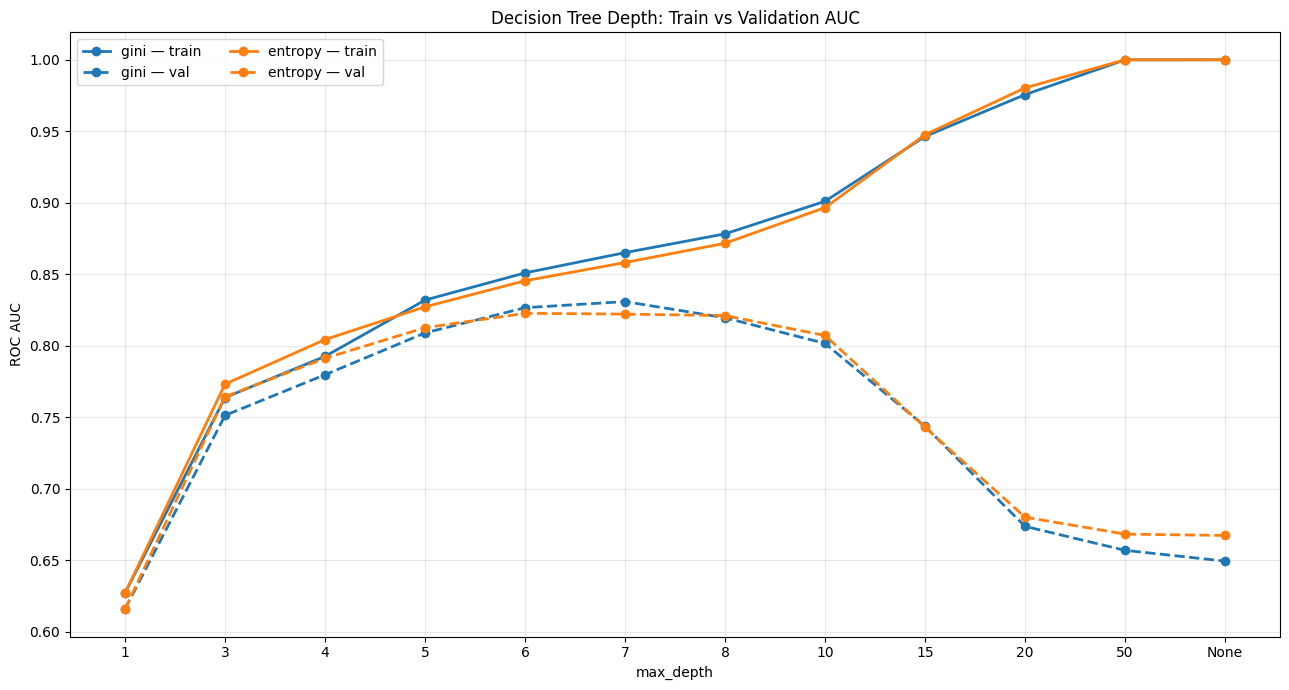

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "gini": {
        1: (0.6269388519663415, 0.6156834917083278),
        3: (0.76368056673405,   0.751227727391097),
        4: (0.7925043846890472, 0.7796468976295183),
        5: (0.8318960344919099, 0.8089078122463704),
        6: (0.8508945917538354, 0.8265583556132536),
        7: (0.86506732038388,   0.8308416731281875),
        8: (0.8782239311861049, 0.8195153805179192),
        10: (0.9009813612178578, 0.801561076304176),
        15: (0.946389845674895, 0.7436098639051947),
        20: (0.9756219505992333, 0.6735967001345278),
        50: (0.999966155893224, 0.656829217832431),
        None: (0.9999999996550735, 0.6492493025950099),
    },
    "entropy": {
        1: (0.6269388519663415, 0.6156834917083278),
        3: (0.7730876292520837, 0.764287931563857),
        4: (0.8042783641448631, 0.7911985642899207),
        5: (0.8271866971274062, 0.8125879795428639),
        6: (0.8454104857208755, 0.822623157409719),
        7: (0.8581629948925069, 0.8220818265770772),
        8: (0.8716403526341401, 0.8210546298058339),
        10: (0.8965747917550799, 0.80713026087066),
        15: (0.947567693525421, 0.7429045691228395),
        20: (0.9803715594318309, 0.6800038167686933),
        50: (0.9999998652199509, 0.6681527030908825),
        None: (0.9999999996550735, 0.6672242978179002),
    }
}

rows = []
for criterion, vals in results.items():
    for depth, (train_auc, val_auc) in vals.items():
        rows.append({
            "criterion": criterion,
            "max_depth": "None" if depth is None else str(depth),
            "depth_sort": 999 if depth is None else depth,
            "train_auc": train_auc,
            "val_auc": val_auc,
        })

df_plot = pd.DataFrame(rows).sort_values(["criterion", "depth_sort"])

fig, ax = plt.subplots(figsize=(13, 7))

colors = {
    "gini": "tab:blue",
    "entropy": "tab:orange",
}

for criterion in ["gini", "entropy"]:
    sub = df_plot[df_plot["criterion"] == criterion]

    ax.plot(
        sub["max_depth"],
        sub["train_auc"],
        marker="o",
        linewidth=2,
        linestyle="-",
        color=colors[criterion],
        label=f"{criterion} — train",
    )

    ax.plot(
        sub["max_depth"],
        sub["val_auc"],
        marker="o",
        linewidth=2,
        linestyle="--",
        color=colors[criterion],
        label=f"{criterion} — val",
    )

ax.set_title("Decision Tree Depth: Train vs Validation AUC")
ax.set_xlabel("max_depth")
ax.set_ylabel("ROC AUC")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

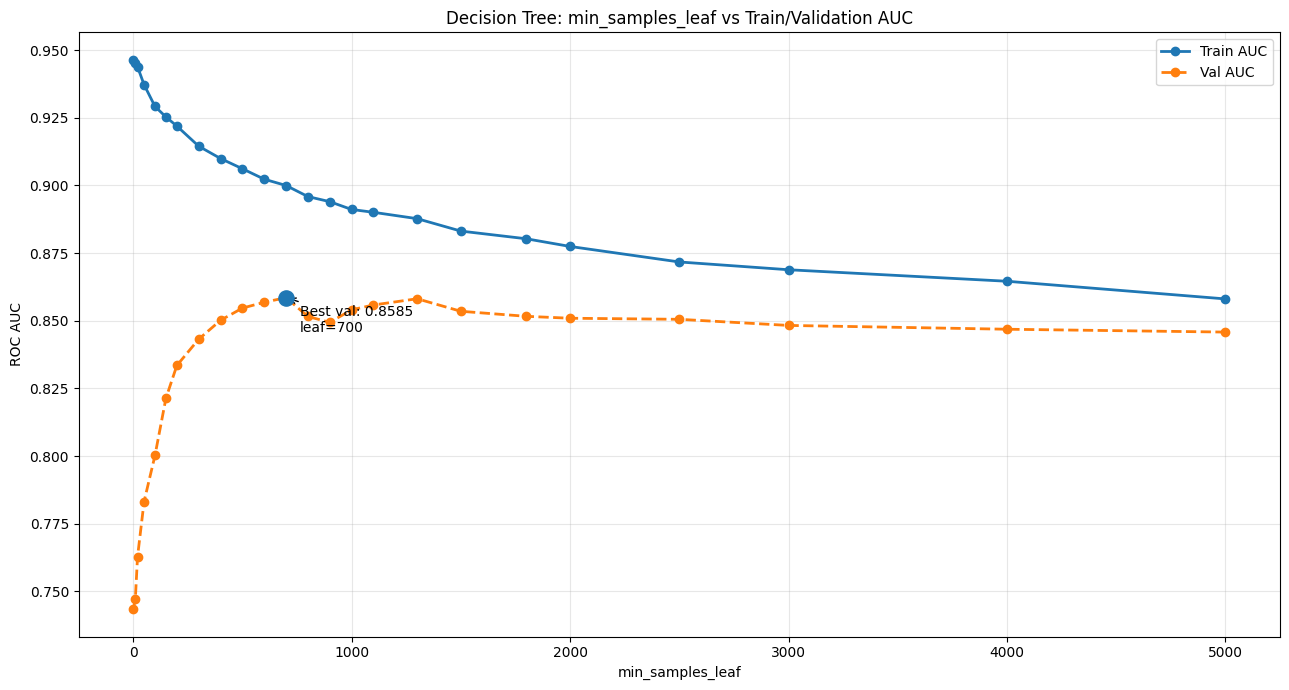

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    1:    (0.9463999063200187, 0.7434438804299786),
    10:   (0.9451524174542824, 0.7472848219403772),
    20:   (0.9438184095411983, 0.7627568391605849),
    50:   (0.9372020832314938, 0.7831802506100869),
    100:  (0.9291538881727984, 0.8002531789387448),
    150:  (0.9252840293357822, 0.8213584021818593),
    200:  (0.9219129617968045, 0.8334536075101108),
    300:  (0.9144814426343206, 0.8431742447602960),
    400:  (0.9099291527421541, 0.8501518110562838),
    500:  (0.9061479644318364, 0.8546575473119100),
    600:  (0.9022849213434325, 0.8568176440874185),
    700:  (0.8999547882351735, 0.8585222177665841),
    800:  (0.8958660693635700, 0.8515650446429661),
    900:  (0.8939859519211851, 0.8493862514039546),
    1000: (0.8910982209012825, 0.8540320958441976),
    1100: (0.8900552716683582, 0.8558072702902728),
    1300: (0.8877040261234124, 0.8581107879639724),
    1500: (0.8831153266470289, 0.8534857190800905),
    1800: (0.8802732851152232, 0.8516217297070294),
    2000: (0.8774362585567481, 0.8509136006714708),
    2500: (0.8717074289479937, 0.8505198008845467),
    3000: (0.8688326150824321, 0.8482588027734776),
    4000: (0.8645811246824071, 0.8468531323194108),
    5000: (0.8580533917220856, 0.845801637831724),
}

df = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in results.items()],
    columns=["min_samples_leaf", "train_auc", "val_auc"]
).sort_values("min_samples_leaf")

best_idx = df["val_auc"].idxmax()
best_row = df.loc[best_idx]

fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    df["min_samples_leaf"],
    df["train_auc"],
    marker="o",
    linewidth=2,
    linestyle="-",
    label="Train AUC",
)

ax.plot(
    df["min_samples_leaf"],
    df["val_auc"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Val AUC",
)

ax.scatter(
    [best_row["min_samples_leaf"]],
    [best_row["val_auc"]],
    s=120,
    zorder=5,
)

ax.annotate(
    f"Best val: {best_row['val_auc']:.4f}\nleaf={int(best_row['min_samples_leaf'])}",
    xy=(best_row["min_samples_leaf"], best_row["val_auc"]),
    xytext=(10, -25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", lw=1),
)

ax.set_title("Decision Tree: min_samples_leaf vs Train/Validation AUC")
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("ROC AUC")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

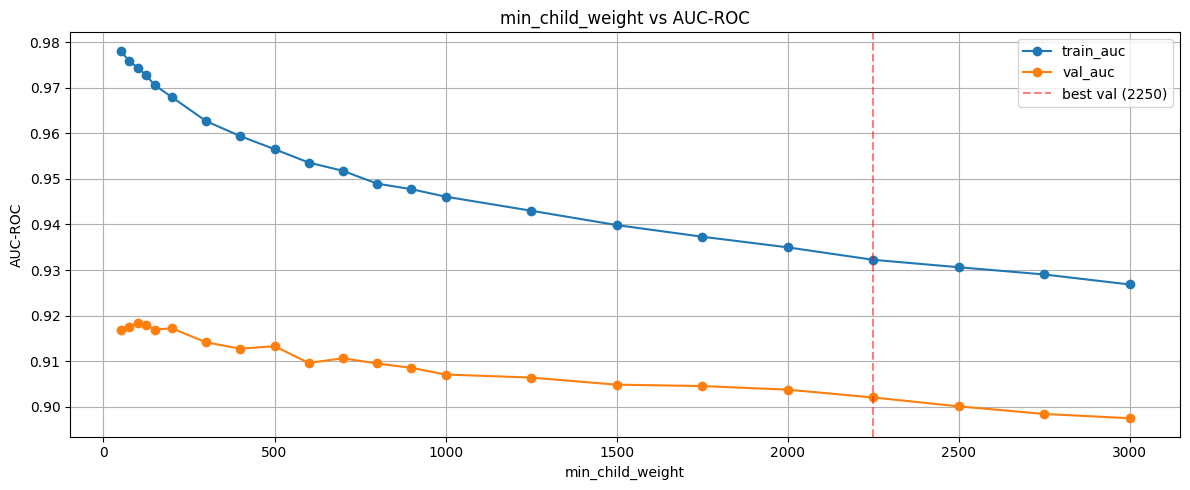

In [5]:
import matplotlib.pyplot as plt

min_child_weights = [50, 75, 100, 125, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000]

train_aucs = [0.9781056829491176, 0.9758484527402131, 0.9744014270563339, 0.972689685164015, 0.9705428240349345, 0.9679220330511655, 0.9626585479890583, 0.9593695621898362, 0.956513254151029, 0.9535738173479262, 0.951768338561523, 0.948951296012529, 0.9477407568859859, 0.9461012234696469, 0.9430199445912751, 0.9398705247832554, 0.9373195728887678, 0.9349843975579808, 0.9322536026853718, 0.9306244665624686, 0.9290324008168191, 0.9268429379821099]

val_aucs = [0.916836178066548, 0.9175716638904821, 0.9184840224865153, 0.9179795158087112, 0.9169518117541826, 0.9172220496306136, 0.9141472711322092, 0.9127566039656071, 0.913304763907323, 0.9096328380426862, 0.910651299549481, 0.9095087976718218, 0.9085583755356518, 0.9070932549393117, 0.9064250955992645, 0.9048663773937535, 0.9045604317700177, 0.9037718695108442, 0.9020569926007121, 0.9001112095624991, 0.8984467151059177, 0.8975095284518247]

plt.figure(figsize=(12, 5))
plt.plot(min_child_weights, train_aucs, marker='o', label='train_auc')
plt.plot(min_child_weights, val_aucs, marker='o', label='val_auc')
plt.axvline(x=2250, color='red', linestyle='--', alpha=0.5, label='best val (2250)')
plt.xlabel('min_child_weight')
plt.ylabel('AUC-ROC')
plt.title('min_child_weight vs AUC-ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

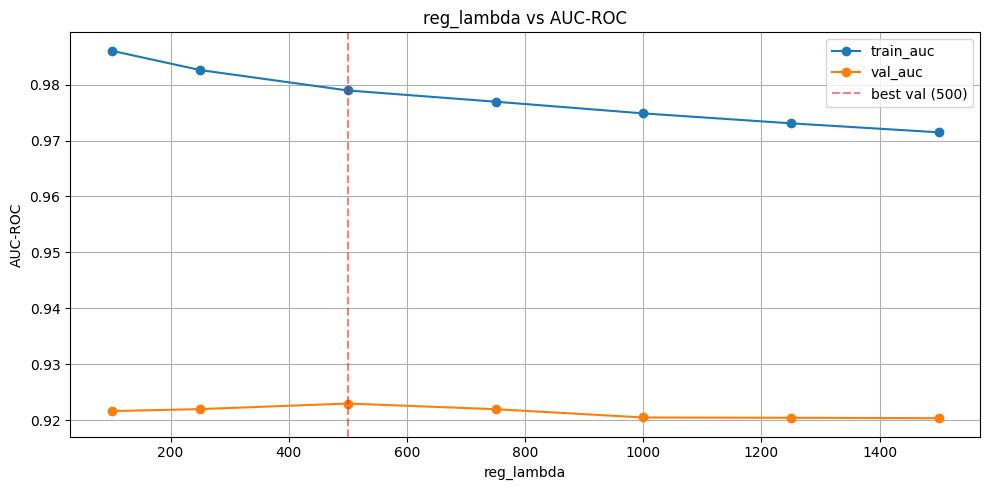

In [10]:
import matplotlib.pyplot as plt

reg_lambdas = [100, 250, 500, 750, 1000, 1250, 1500]
rl_train = [0.9860666162473734, 0.9826076379686535, 0.9789584095017385, 0.9769501889259289, 0.9748588156134286, 0.9730830036145957, 0.9714767356045145]
rl_val   = [0.921636653596974,  0.9219847210271283, 0.9229860982320723, 0.9219704690569532, 0.92048851395735,   0.9204375646531586, 0.9203599483889986]

plt.figure(figsize=(10, 5))
plt.plot(reg_lambdas, rl_train, marker='o', label='train_auc')
plt.plot(reg_lambdas, rl_val,   marker='o', label='val_auc')
plt.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='best val (500)')
plt.xlabel('reg_lambda')
plt.ylabel('AUC-ROC')
plt.title('reg_lambda vs AUC-ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
